# User and Data Prep

In [1]:
import boto3
import sagemaker
from pyathena import connect
import pandas as pd
from sagemaker.session import Session

region = boto3.Session().region_name

boto_session = boto3.Session(region_name=region)

sagemaker_client = boto_session.client(service_name="sagemaker", region_name=region)
featurestore_runtime = boto_session.client(
    service_name="sagemaker-featurestore-runtime", region_name=region
)

feature_store_session = Session(
    boto_session=boto_session,
    sagemaker_client=sagemaker_client,
    sagemaker_featurestore_runtime_client=featurestore_runtime,
)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


In [2]:
sess = sagemaker.Session()
bucket = sess.default_bucket()
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
account_id = boto3.client("sts").get_caller_identity().get("Account")

sm = boto3.Session().client(service_name="sagemaker", region_name=region)

In [3]:
default_s3_bucket_name = feature_store_session.default_bucket()
prefix = "sagemaker-featurestore-maintenance"

print(default_s3_bucket_name)

sagemaker-us-east-1-429874041769


In [4]:
s3_private_path_housing = "s3://{}/vehicle_maintenance.csv".format(default_s3_bucket_name)
print(s3_private_path_housing)

s3://sagemaker-us-east-1-429874041769/vehicle_maintenance.csv


In [5]:
%store s3_private_path_housing

Stored 's3_private_path_housing' (str)


In [6]:
!aws s3 cp "vehicle_maintenance_data.csv" $s3_private_path_housing

upload: ./vehicle_maintenance_data.csv to s3://sagemaker-us-east-1-429874041769/vehicle_maintenance.csv


In [7]:
from sagemaker import get_execution_role

role = get_execution_role()
print(role)

arn:aws:iam::429874041769:role/LabRole


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io

s3_client = boto3.client("s3", region_name=region)

vehicle_maintenance_bucket_name = default_s3_bucket_name
vehicle_maintenance = (
    "vehicle_maintenance.csv"
)


identity_vehicle_maintenance = s3_client.get_object(
    Bucket=vehicle_maintenance_bucket_name, Key=vehicle_maintenance
)


df = pd.read_csv(io.BytesIO(identity_vehicle_maintenance["Body"].read()))

In [9]:
df.head(2)

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,11/23/2023,6/24/2025,Second,20782,6,3,13.622204,New,New,Weak,1
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,9/21/2023,6/4/2025,Second,23489,7,0,13.625307,New,New,Weak,1


# EDA

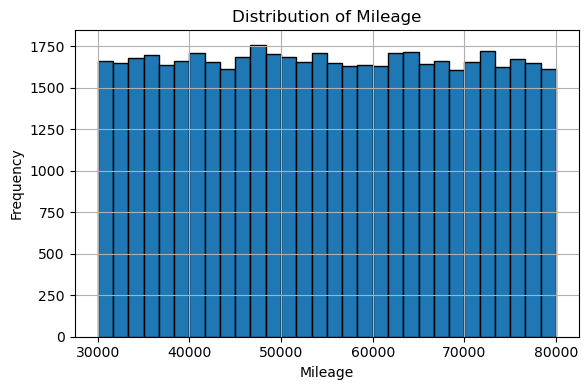

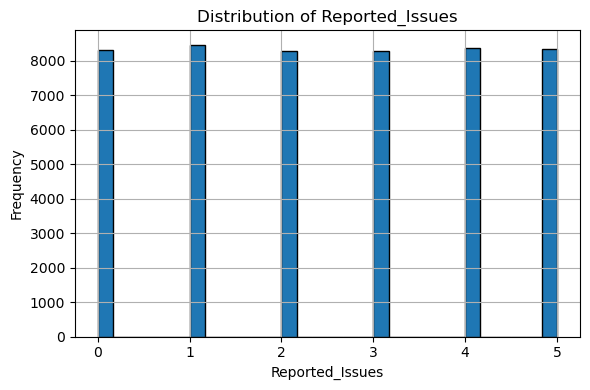

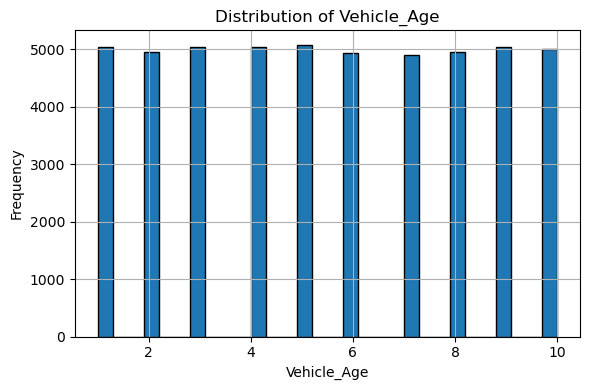

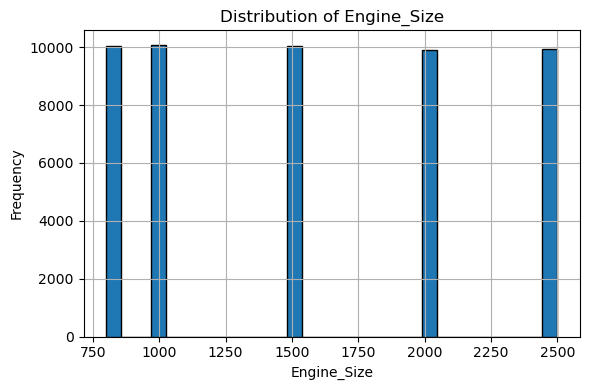

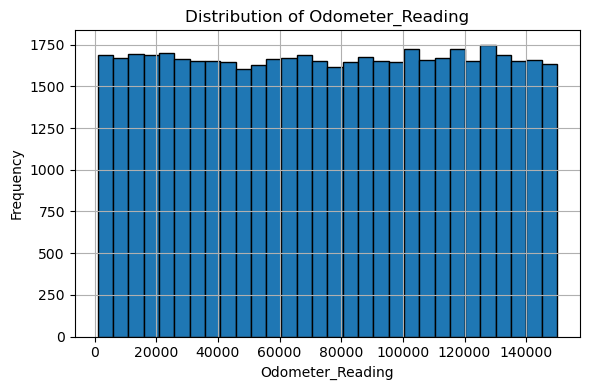

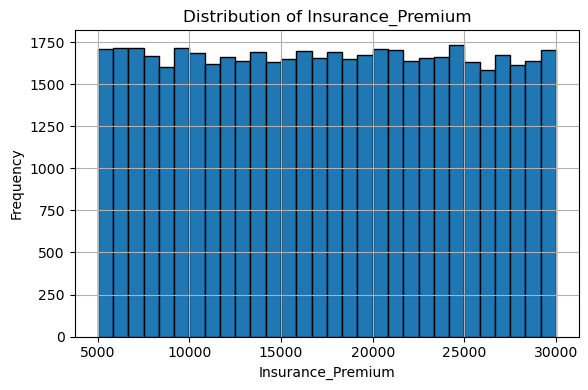

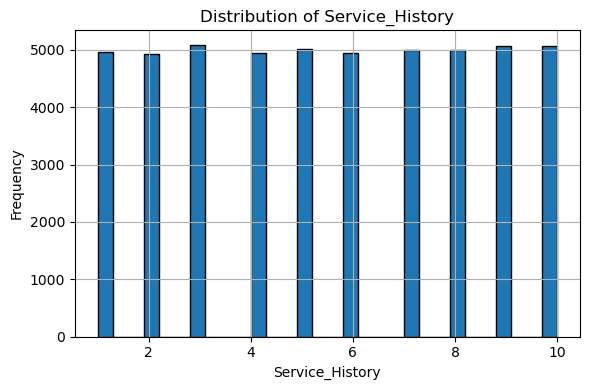

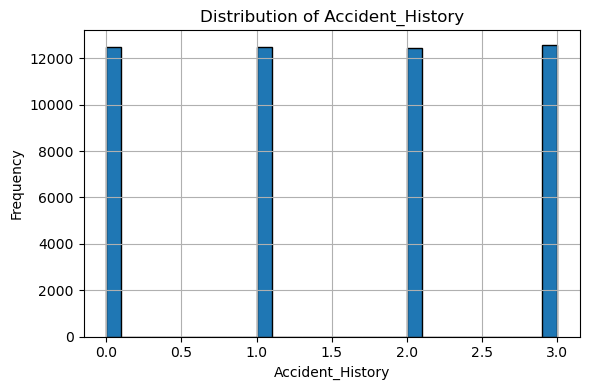

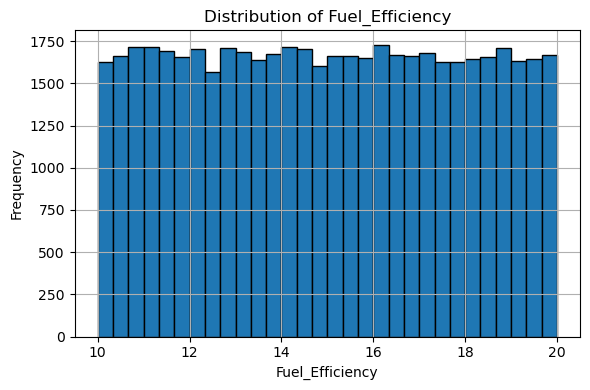

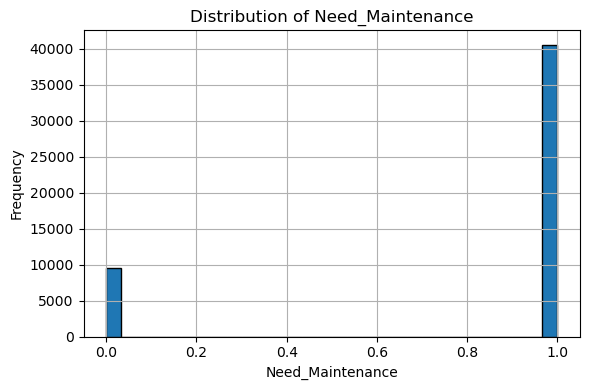

In [10]:
for i in df.columns:
    if df[i].dtype != 'object':
        plt.figure(figsize=(6, 4))
        plt.hist(df[i], bins=30, edgecolor='black') 
        plt.title(f'Distribution of {i}')
        plt.xlabel(i)
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.tight_layout()
        plt.show()


#### Transforming Object To Datetime

In [11]:
df['Last_Service_Date'] = pd.to_datetime(df['Last_Service_Date'])
df['Warranty_Expiry_Date'] = pd.to_datetime(df['Warranty_Expiry_Date'])

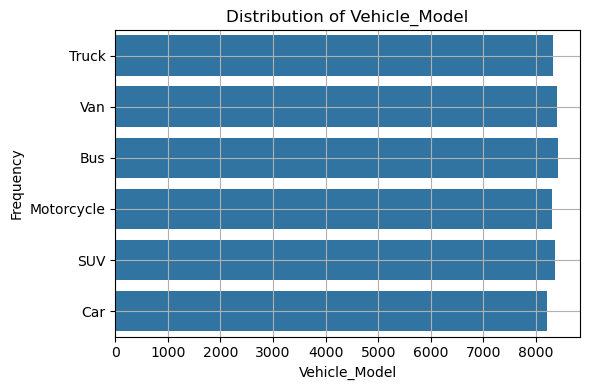

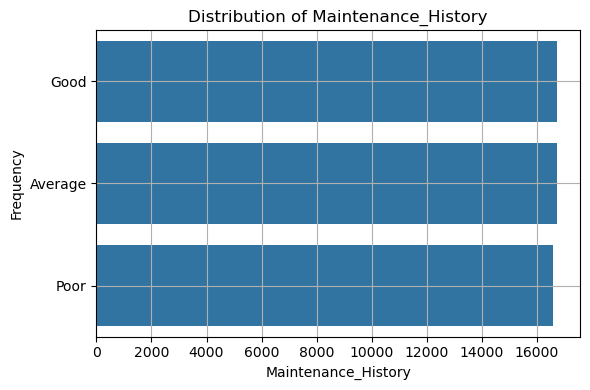

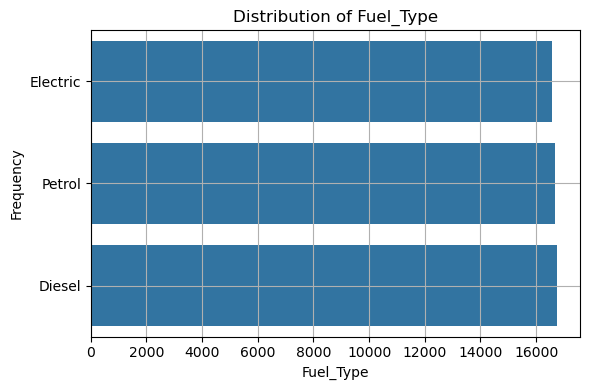

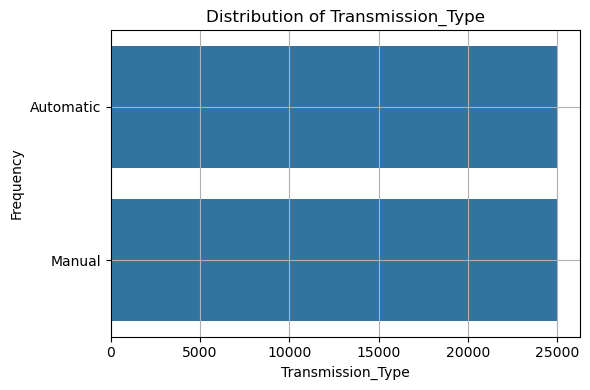

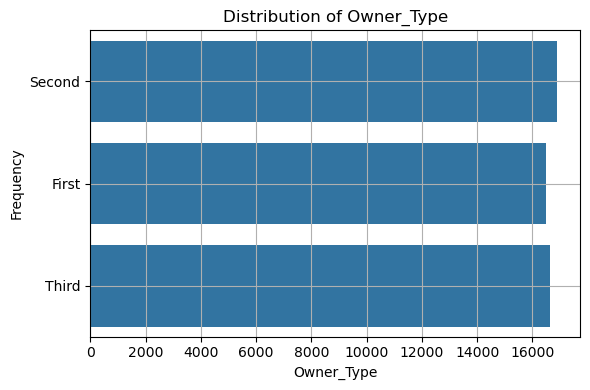

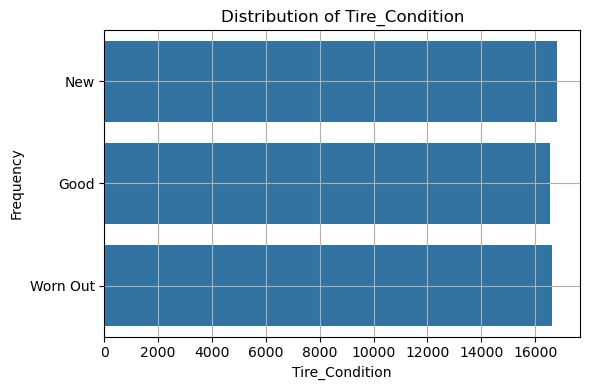

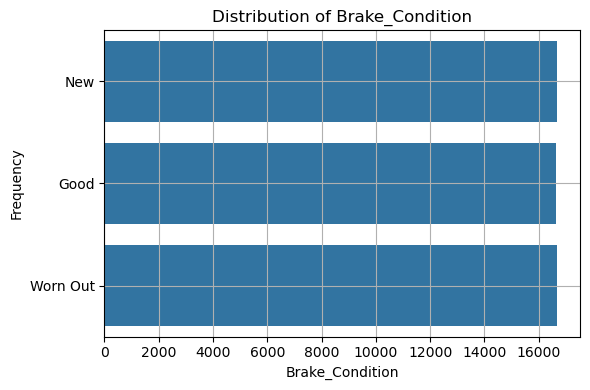

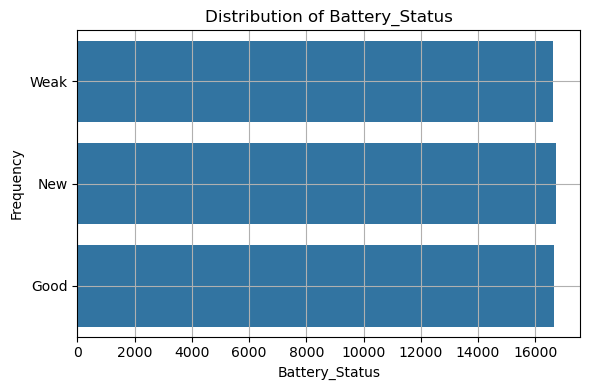

In [12]:
import seaborn as sns
for i in df.columns:
    if df[i].dtype == 'object':
        plt.figure(figsize=(6, 4))
        sns.countplot(df[i]) 
        plt.title(f'Distribution of {i}')
        plt.xlabel(i)
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

#### Issues per Vehicle Type

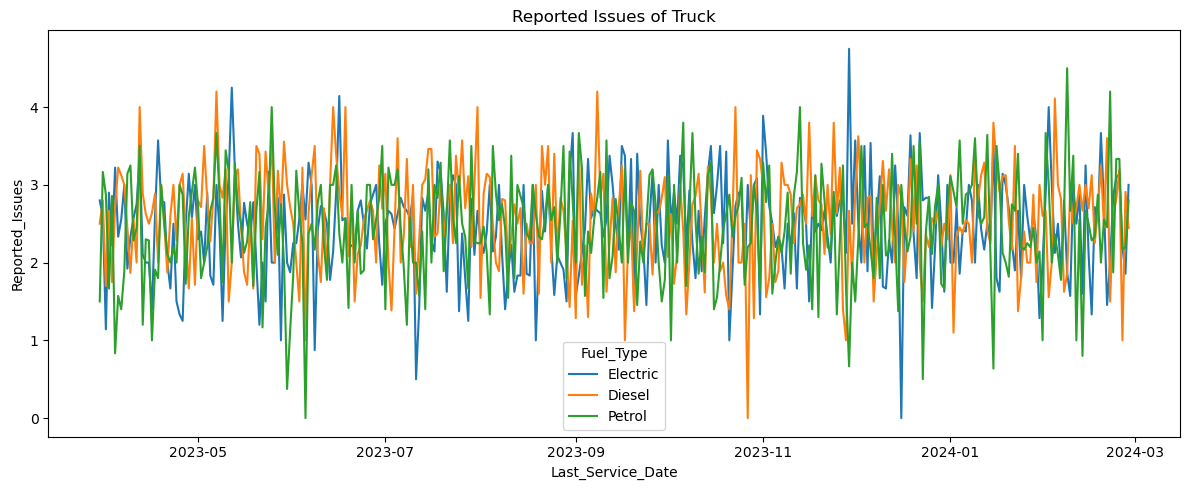

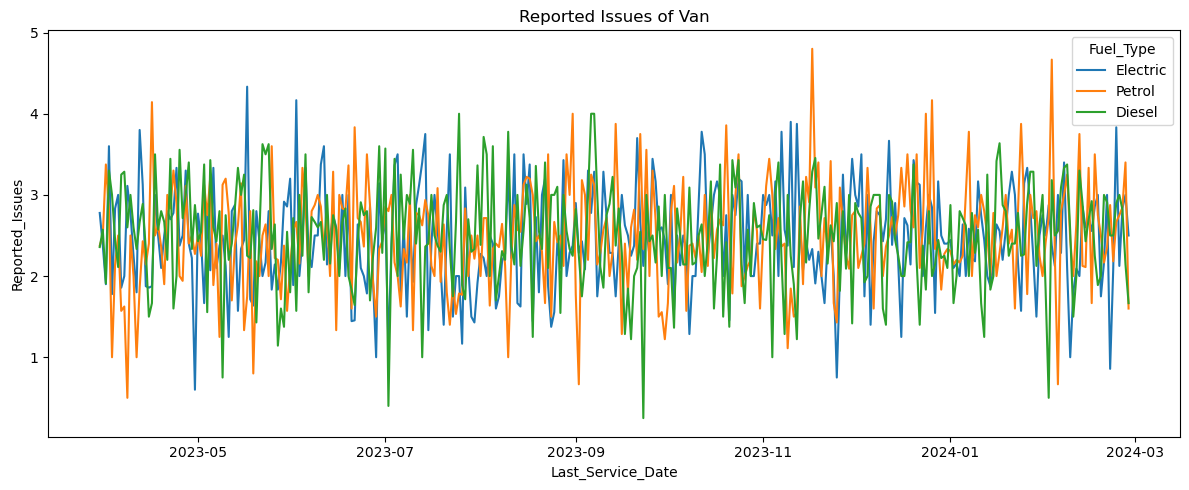

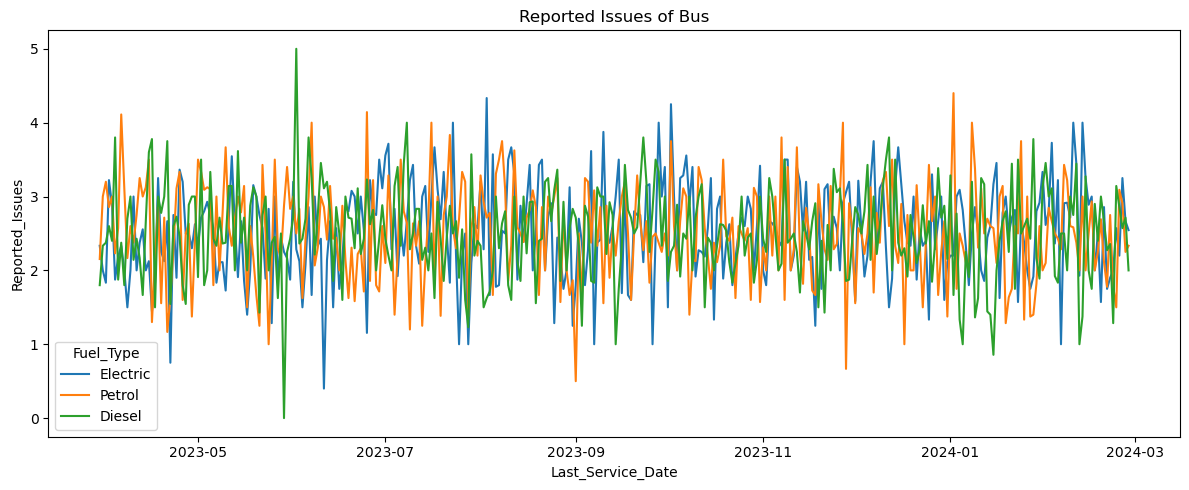

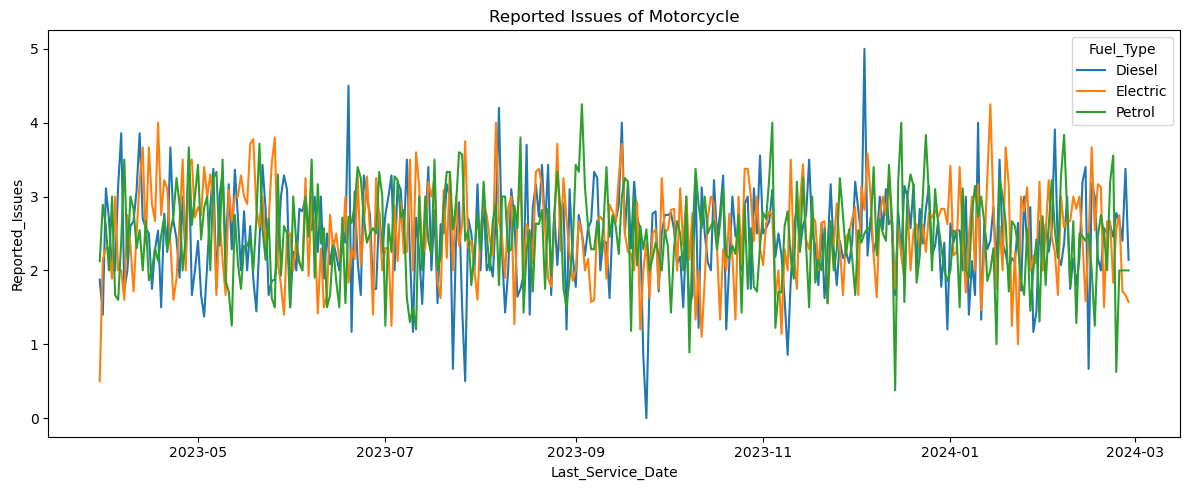

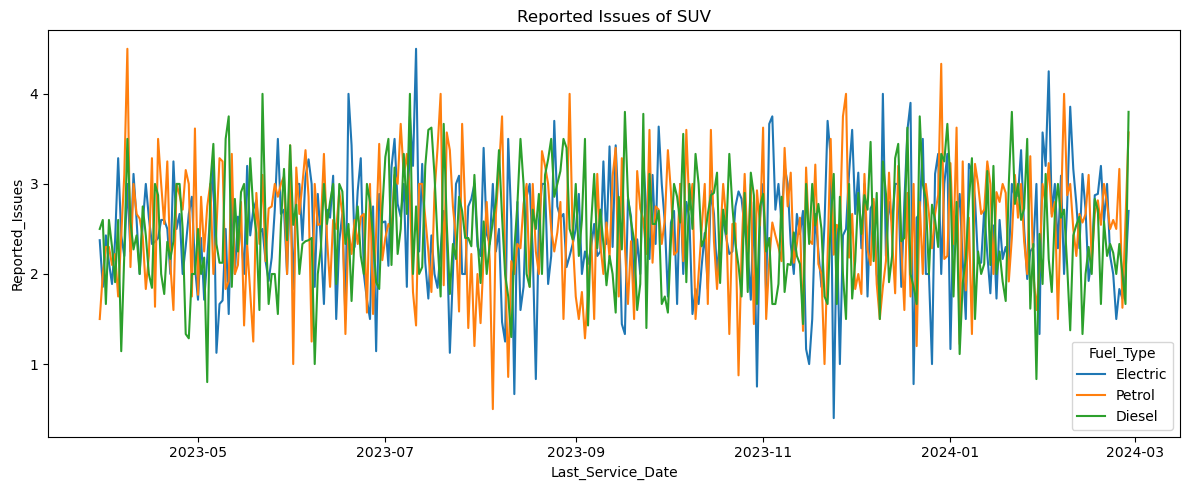

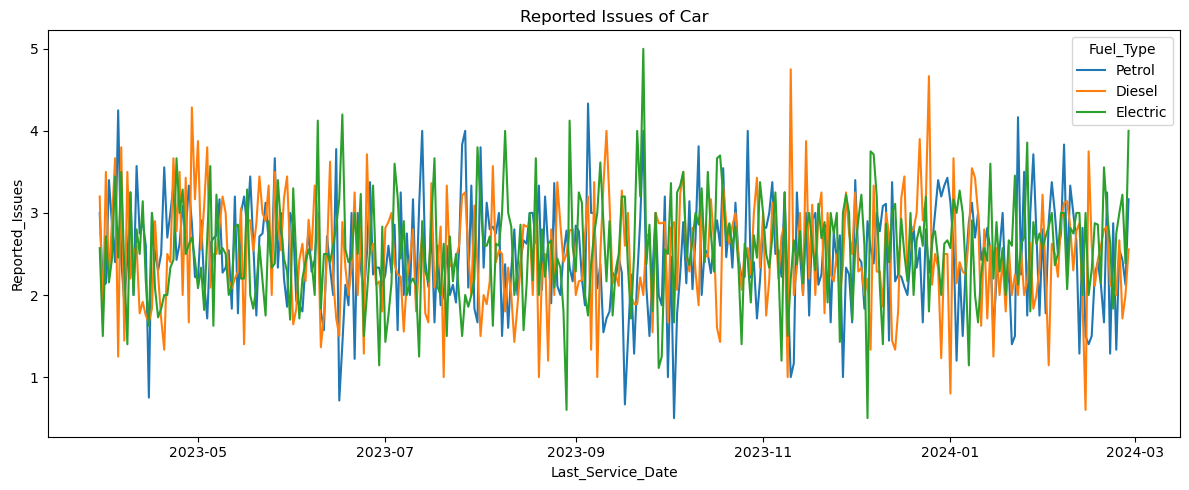

In [13]:
Vehicles = ['Truck', 'Van', 'Bus', 'Motorcycle', 'SUV', 'Car']
for i in Vehicles:
    subset = df[df['Vehicle_Model'] == i] 
    plt.figure(figsize=(12,5))
    sns.lineplot(data = subset, x = 'Last_Service_Date', y = 'Reported_Issues', hue= 'Fuel_Type', errorbar=None)
    plt.title(f'Reported Issues of {i}')
    plt.tight_layout()
    plt.show()

#### Maintenance Conditions

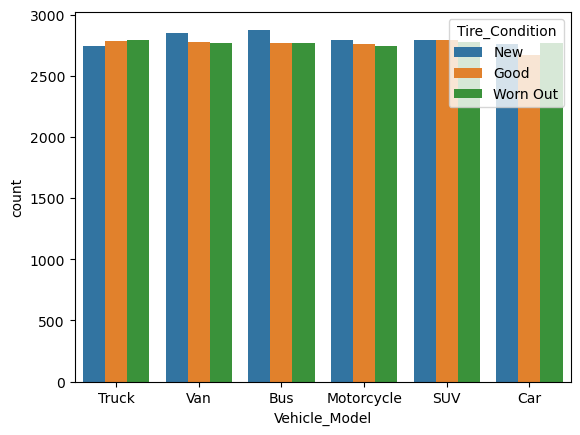

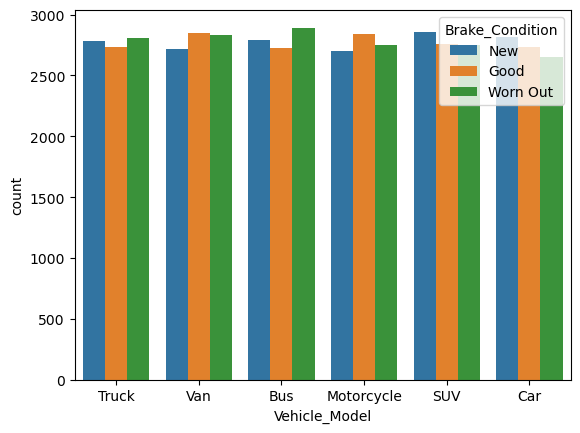

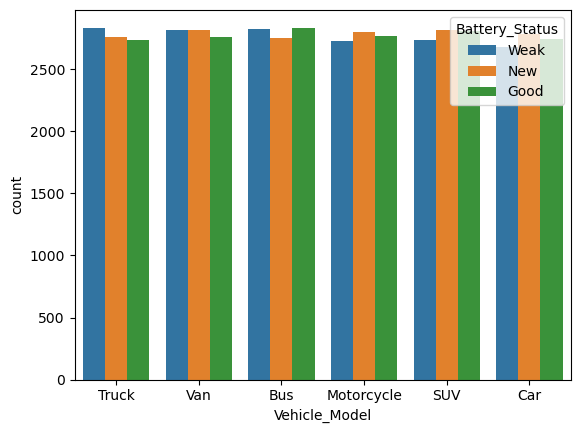

In [14]:
sns.countplot(data= df, x = 'Vehicle_Model', hue= 'Tire_Condition')
plt.show()
sns.countplot(data= df, x = 'Vehicle_Model', hue= 'Brake_Condition')
plt.show()
sns.countplot(data= df, x = 'Vehicle_Model', hue= 'Battery_Status')
plt.show()

#### Vehicle Age and Odometer Reading per vehicle Type

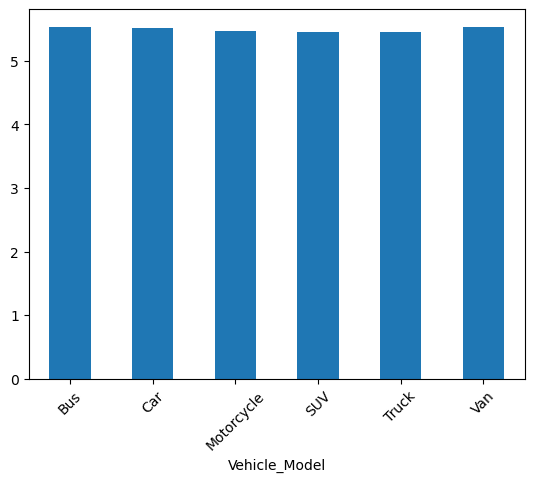

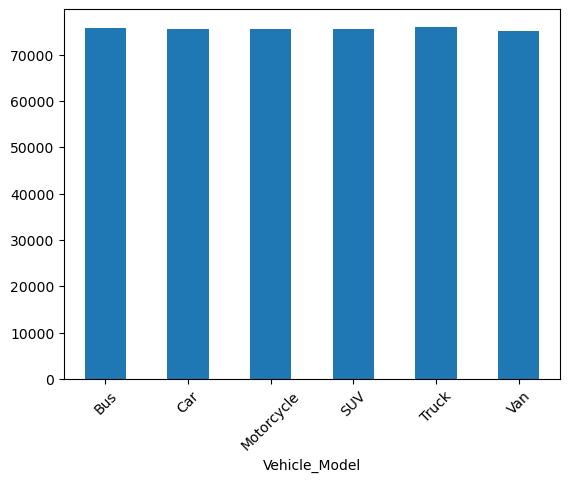

In [15]:
df.groupby('Vehicle_Model')['Vehicle_Age'].mean().plot(kind = 'bar')
plt.xticks(rotation = 45)
plt.show()
df.groupby('Vehicle_Model')['Odometer_Reading'].mean().plot(kind = 'bar')
plt.xticks(rotation = 45)
plt.show()

#### Correlation Analysis

<Axes: >

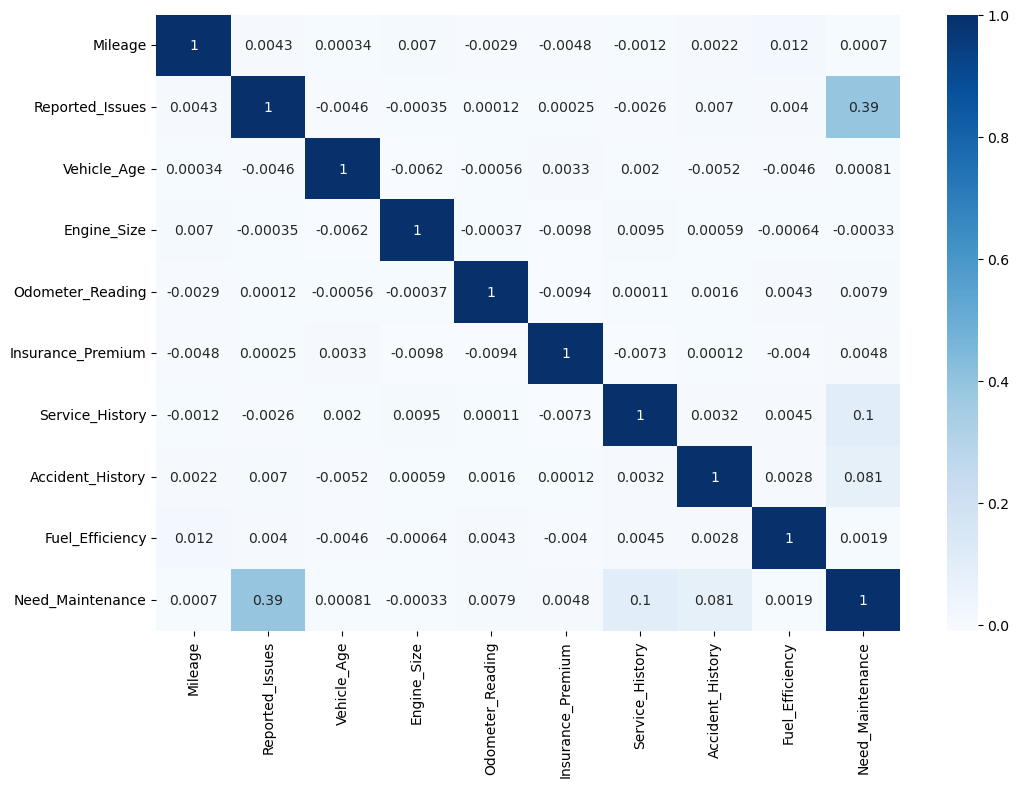

In [16]:
corr_mat = df.corr(numeric_only= True)
plt.figure(figsize=(12,8))
sns.heatmap(corr_mat, cmap="Blues", annot= True)

#### Feature Engineering

In [17]:
df[['Service_History', 'Accident_History', 'Reported_Issues']]

df['Hist_Record'] = (df['Service_History'] + df['Accident_History'] + df['Reported_Issues']) /  3

df_updated = df.copy()

df_updated.drop(columns= ['Service_History', 'Accident_History', 'Reported_Issues'], axis= 1, inplace= True)

df_updated.head()

,Vehicle_Model,Mileage,Maintenance_History,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance,Hist_Record
0,Truck,58765,Good,4,Electric,Automatic,2000,28524,2023-11-23,2025-06-24,Second,20782,13.622204,New,New,Weak,1,3.000000
1,Van,60353,Average,7,Electric,Automatic,2500,133630,2023-09-21,2025-06-04,Second,23489,13.625307,New,New,Weak,1,2.666667
2,Bus,68072,Poor,2,Electric,Automatic,1500,34022,2023-06-27,2025-04-27,First,17979,14.306302,New,Good,Weak,1,2.333333
3,Bus,60849,Average,5,Petrol,Automatic,2500,81636,2023-08-24,2025-11-05,Second,6220,18.709467,New,Worn Out,New,1,4.666667
4,Bus,45742,Poor,1,Petrol,Manual,2000,97162,2023-05-25,2025-09-14,Third,16446,16.977483,Good,Good,Weak,1,4.333333


##### Encoding

In [18]:
object_col = []

for i in df_updated.columns:
    if df[i].dtype == 'object':
        object_col.append(i)

object_col

['Vehicle_Model',
 'Maintenance_History',
 'Fuel_Type',
 'Transmission_Type',
 'Owner_Type',
 'Tire_Condition',
 'Brake_Condition',
 'Battery_Status']

In [19]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for encoded in object_col:
    df_updated[encoded] = encoder.fit_transform(df_updated[encoded])

df_updated

,Vehicle_Model,Mileage,Maintenance_History,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance,Hist_Record
0,4,58765,1,4,1,0,2000,28524,2023-11-23,2025-06-24,1,20782,13.622204,1,1,2,1,3.000000
1,5,60353,0,7,1,0,2500,133630,2023-09-21,2025-06-04,1,23489,13.625307,1,1,2,1,2.666667
2,0,68072,2,2,1,0,1500,34022,2023-06-27,2025-04-27,0,17979,14.306302,1,0,2,1,2.333333
3,0,60849,0,5,2,0,2500,81636,2023-08-24,2025-11-05,1,6220,18.709467,1,2,1,1,4.666667
4,0,45742,2,1,2,1,2000,97162,2023-05-25,2025-09-14,2,16446,16.977483,0,0,2,1,4.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,1,77229,1,6,0,0,2500,97404,2023-11-24,2025-09-15,2,5217,10.357298,1,0,2,1,2.666667
49996,4,54742,1,4,0,1,800,13421,2023-07-14,2025-01-21,1,15856,14.924022,2,1,0,1,3.000000
49997,5,75601,2,4,1,0,1500,124851,2023-09-09,2024-11-09,0,6019,19.859243,2,2,2,1,3.333333
49998,1,66181,1,7,1,1,2500,103182,2023-08-26,2025-05-22,2,5030,10.720555,1,0,2,1,2.666667


#### Feature Engineering

In [20]:
df_updated['service_status'] = df_updated['Tire_Condition'] + df_updated['Brake_Condition'] + df_updated['Battery_Status'] / 3

df_updated.drop(columns=['Tire_Condition', 'Brake_Condition', 'Battery_Status'], inplace= True, axis = 1)

df_updated.head(2)

,Vehicle_Model,Mileage,Maintenance_History,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Fuel_Efficiency,Need_Maintenance,Hist_Record,service_status
0,4,58765,1,4,1,0,2000,28524,2023-11-23,2025-06-24,1,20782,13.622204,1,3.000000,2.666667
1,5,60353,0,7,1,0,2500,133630,2023-09-21,2025-06-04,1,23489,13.625307,1,2.666667,2.666667


#### Feature Engineering Miles Per Year

In [21]:
df_updated['miles_per_year'] = df_updated['Mileage'] / df['Vehicle_Age']

df_updated.drop(columns=['Mileage', 'Vehicle_Age'], inplace= True, axis= 1)

df_updated.describe()

,Vehicle_Model,Maintenance_History,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Fuel_Efficiency,Need_Maintenance,Hist_Record,service_status,miles_per_year
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2.503700,0.996800,0.99884,0.500180,1556.292000,75551.187060,2023-09-13 10:33:48.096000,2025-04-11 15:56:30.336000256,1.002700,17465.340700,14.990323,0.809960,3.171513,2.335213,16135.339941
min,0.000000,0.000000,0.00000,0.000000,800.000000,1001.000000,2023-03-30 00:00:00,2024-04-28 00:00:00,0.000000,5000.000000,10.000098,0.000000,0.333333,0.000000,3000.500000
25%,1.000000,0.000000,0.00000,0.000000,1000.000000,38009.000000,2023-06-21 00:00:00,2024-10-18 00:00:00,0.000000,11189.750000,12.489037,1.000000,2.333333,1.333333,6780.325000
50%,3.000000,1.000000,1.00000,1.000000,1500.000000,75598.500000,2023-09-14 00:00:00,2025-04-12 00:00:00,1.000000,17477.500000,14.986352,1.000000,3.333333,2.333333,10030.166667
75%,4.000000,2.000000,2.00000,1.000000,2000.000000,112999.500000,2023-12-06 00:00:00,2025-10-04 00:00:00,2.000000,23692.000000,17.474676,1.000000,4.000000,3.333333,18389.500000
max,5.000000,2.000000,2.00000,1.000000,2500.000000,149999.000000,2024-02-28 00:00:00,2026-03-29 00:00:00,2.000000,30000.000000,19.999968,1.000000,6.000000,4.666667,79990.000000
std,1.711422,0.815943,0.81754,0.500005,627.677218,43088.105658,NaN,NaN,0.813945,7223.393401,2.885583,0.392336,1.176649,1.186846,15588.301259


#### Correlation #2

<Axes: >

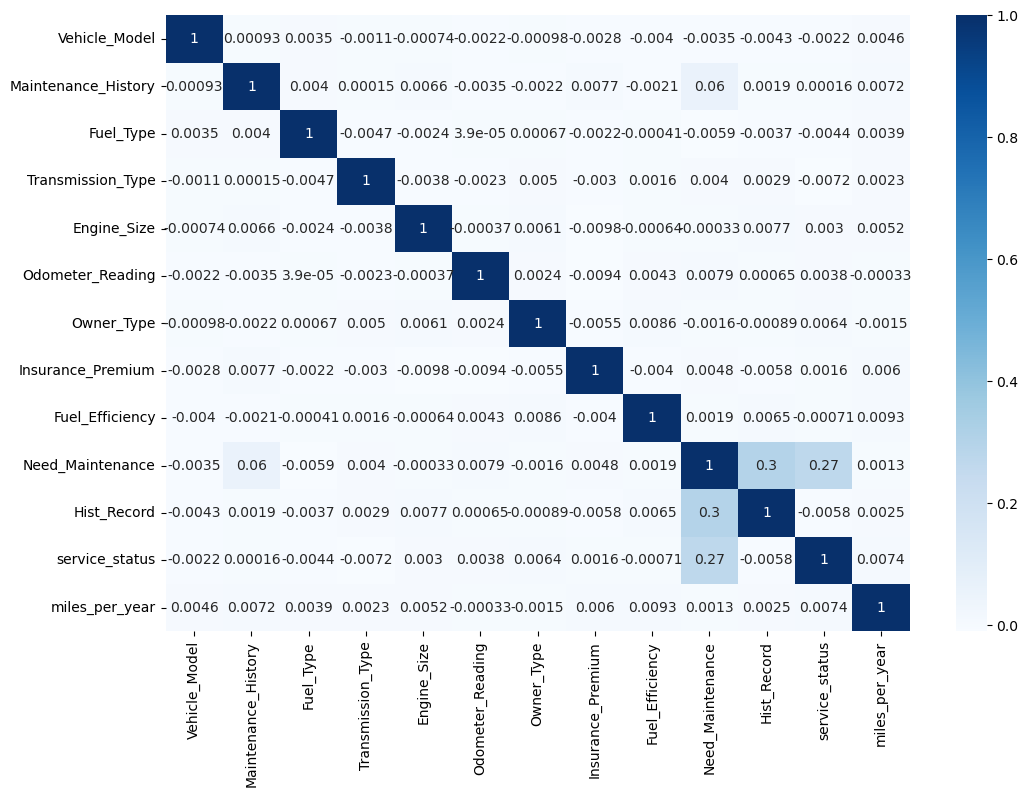

In [22]:
corr_mat = df_updated.corr(numeric_only= True)
plt.figure(figsize=(12,8))
sns.heatmap(corr_mat, cmap="Blues", annot= True)

#### Feature Engineering

<Axes: >

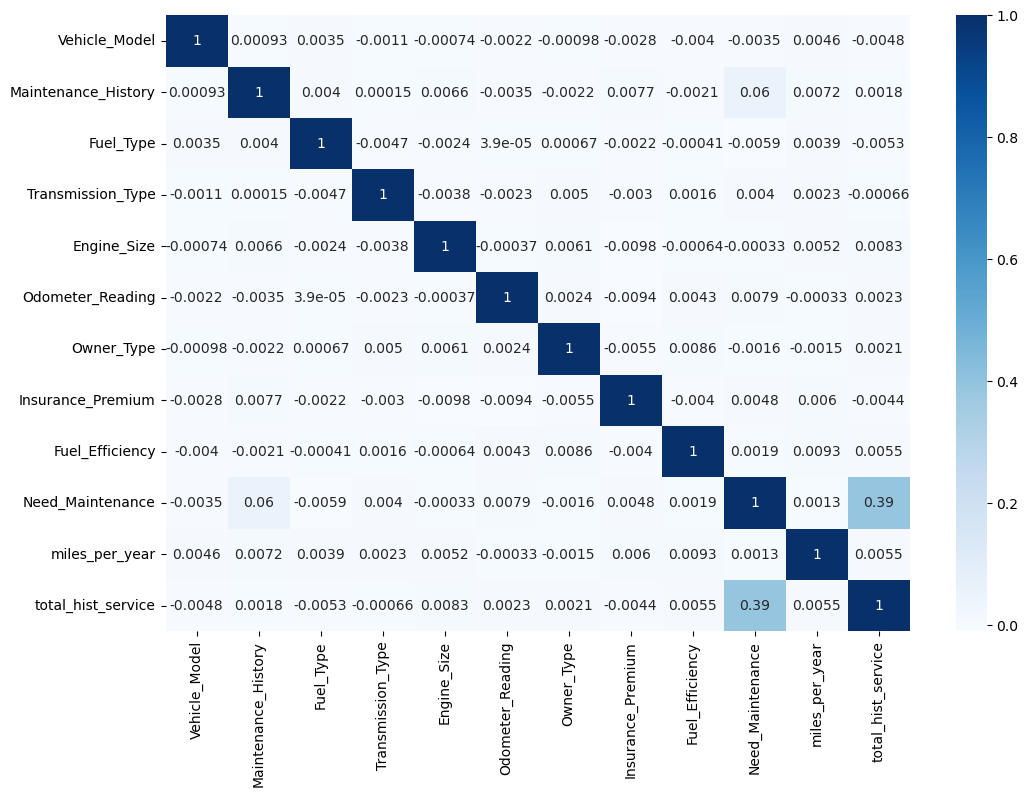

In [23]:
df_updated['total_hist_service'] = df_updated['Hist_Record'] + df_updated['service_status'] / 2 

df_updated.drop(columns=['Hist_Record', 'service_status'], inplace= True, axis= 1)

corr_mat = df_updated.corr(numeric_only= True)
plt.figure(figsize=(12,8))
sns.heatmap(corr_mat, cmap="Blues", annot= True)


#### Datetime Feature Engineering

In [24]:
df_updated['last_Service_month'] = df_updated['Last_Service_Date'].dt.month

In [25]:
df_updated['Last_Service_Date'].dt.dayofweek.value_counts()

Last_Service_Date
1    7254
4    7203
0    7196
5    7150
3    7126
2    7066
6    7005
Name: count, dtype: int64

In [26]:
df_updated['week_number'] = df_updated['Last_Service_Date'].dt.isocalendar().week
df_updated.head(3)

,Vehicle_Model,Maintenance_History,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Fuel_Efficiency,Need_Maintenance,miles_per_year,total_hist_service,last_Service_month,week_number
0,4,1,1,0,2000,28524,2023-11-23,2025-06-24,1,20782,13.622204,1,14691.250000,4.333333,11,47
1,5,0,1,0,2500,133630,2023-09-21,2025-06-04,1,23489,13.625307,1,8621.857143,4.000000,9,38
2,0,2,1,0,1500,34022,2023-06-27,2025-04-27,0,17979,14.306302,1,34036.000000,3.166667,6,26


In [27]:
df_updated.drop(columns=['Last_Service_Date', 'Warranty_Expiry_Date'], axis= 1, inplace= True)

df_updated.head(3)

,Vehicle_Model,Maintenance_History,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Owner_Type,Insurance_Premium,Fuel_Efficiency,Need_Maintenance,miles_per_year,total_hist_service,last_Service_month,week_number
0,4,1,1,0,2000,28524,1,20782,13.622204,1,14691.250000,4.333333,11,47
1,5,0,1,0,2500,133630,1,23489,13.625307,1,8621.857143,4.000000,9,38
2,0,2,1,0,1500,34022,0,17979,14.306302,1,34036.000000,3.166667,6,26


#### Feature Sanitization

In [28]:
import re

def sanitize_column_name(name):
    # Replace all invalid characters with underscores
    name = re.sub(r'[^a-zA-Z0-9_-]', '_', name)
    # Truncate to 63 characters max
    name = name[:40]
    # Remove leading/trailing hyphens or underscores
    name = re.sub(r'^[-_]+|[-_]+$', '', name)
    return name

# Forcefully sanitize all columns and overwrite DataFrame
df_updated.columns = [sanitize_column_name(col) for col in df_updated.columns]

#### Ingestion Time Tracking

In [29]:
# Time of ingestion time tracking
from time import gmtime, strftime, sleep

housing_feature_group_name = "maintenance-feature-group-" + strftime("%d-%H-%M-%S", gmtime())

#### Feature Setup

In [30]:
housing_feature_group_name

'maintenance-feature-group-19-06-35-13'

In [31]:
from sagemaker.feature_store.feature_group import FeatureGroup

feature_group = FeatureGroup(
    name=housing_feature_group_name, sagemaker_session=feature_store_session
)

In [32]:
df_updated['vehicle_id'] = df_updated.index.astype(str)


In [33]:
import time

current_time_sec = int(round(time.time()))


def cast_object_to_string(data_frame):
    for label in data_frame.columns:
        if data_frame.dtypes[label] == "object":
            data_frame[label] = data_frame[label].astype("str").astype("string")


# cast object dtype to string. The SageMaker FeatureStore Python SDK will then map the string dtype to String feature type.
cast_object_to_string(df)

# record identifier and event time feature names
record_identifier_feature_name = "vehicle_id"
event_time_feature_name = "EventTime"

# append EventTime feature
df_updated[event_time_feature_name] = pd.Series(
    [current_time_sec] * len(df), dtype="float64"
)
# Convert all boolean columns to integers
bool_cols = df_updated.select_dtypes(include='bool').columns
df_updated[bool_cols] = df_updated[bool_cols].astype(int)
# Converting categories to strings

# load feature definitions to the feature group. SageMaker FeatureStore Python SDK will auto-detect the data schema based on input data.
feature_group.load_feature_definitions(data_frame=df_updated)

[FeatureDefinition(feature_name='Vehicle_Model', feature_type=<FeatureTypeEnum.INTEGRAL: 'Integral'>, collection_type=None),
 FeatureDefinition(feature_name='Maintenance_History', feature_type=<FeatureTypeEnum.INTEGRAL: 'Integral'>, collection_type=None),
 FeatureDefinition(feature_name='Fuel_Type', feature_type=<FeatureTypeEnum.INTEGRAL: 'Integral'>, collection_type=None),
 FeatureDefinition(feature_name='Transmission_Type', feature_type=<FeatureTypeEnum.INTEGRAL: 'Integral'>, collection_type=None),
 FeatureDefinition(feature_name='Engine_Size', feature_type=<FeatureTypeEnum.INTEGRAL: 'Integral'>, collection_type=None),
 FeatureDefinition(feature_name='Odometer_Reading', feature_type=<FeatureTypeEnum.INTEGRAL: 'Integral'>, collection_type=None),
 FeatureDefinition(feature_name='Owner_Type', feature_type=<FeatureTypeEnum.INTEGRAL: 'Integral'>, collection_type=None),
 FeatureDefinition(feature_name='Insurance_Premium', feature_type=<FeatureTypeEnum.INTEGRAL: 'Integral'>, collection_type

# Creating Feature Groups in Sagemaker Feature Store

In [34]:
def wait_for_feature_group_creation_complete(feature_group):
    status = feature_group.describe().get("FeatureGroupStatus")
    while status == "Creating":
        print("Waiting for Feature Group Creation")
        time.sleep(5)
        status = feature_group.describe().get("FeatureGroupStatus")
    if status != "Created":
        raise RuntimeError(f"Failed to create feature group {feature_group.name}")
    print(f"FeatureGroup {feature_group.name} successfully created.")


feature_group.create(
    s3_uri=f"s3://{default_s3_bucket_name}/{prefix}",
    record_identifier_name=record_identifier_feature_name,
    event_time_feature_name=event_time_feature_name,
    role_arn=role,
    enable_online_store=True,
)


wait_for_feature_group_creation_complete(feature_group=feature_group)


Waiting for Feature Group Creation
Waiting for Feature Group Creation
Waiting for Feature Group Creation
Waiting for Feature Group Creation
FeatureGroup maintenance-feature-group-19-06-35-13 successfully created.


In [35]:
feature_group.describe()

{'FeatureGroupArn': 'arn:aws:sagemaker:us-east-1:429874041769:feature-group/maintenance-feature-group-19-06-35-13',
 'FeatureGroupName': 'maintenance-feature-group-19-06-35-13',
 'RecordIdentifierFeatureName': 'vehicle_id',
 'EventTimeFeatureName': 'EventTime',
 'FeatureDefinitions': [{'FeatureName': 'Vehicle_Model',
   'FeatureType': 'Integral'},
  {'FeatureName': 'Maintenance_History', 'FeatureType': 'Integral'},
  {'FeatureName': 'Fuel_Type', 'FeatureType': 'Integral'},
  {'FeatureName': 'Transmission_Type', 'FeatureType': 'Integral'},
  {'FeatureName': 'Engine_Size', 'FeatureType': 'Integral'},
  {'FeatureName': 'Odometer_Reading', 'FeatureType': 'Integral'},
  {'FeatureName': 'Owner_Type', 'FeatureType': 'Integral'},
  {'FeatureName': 'Insurance_Premium', 'FeatureType': 'Integral'},
  {'FeatureName': 'Fuel_Efficiency', 'FeatureType': 'Fractional'},
  {'FeatureName': 'Need_Maintenance', 'FeatureType': 'Integral'},
  {'FeatureName': 'miles_per_year', 'FeatureType': 'Fractional'},
  

In [36]:
sagemaker_client.list_feature_groups()

{'FeatureGroupSummaries': [{'FeatureGroupName': 'vehicle-maintenance-feature-group',
   'FeatureGroupArn': 'arn:aws:sagemaker:us-east-1:429874041769:feature-group/vehicle-maintenance-feature-group',
   'CreationTime': datetime.datetime(2025, 5, 24, 13, 50, 33, 966000, tzinfo=tzlocal()),
   'FeatureGroupStatus': 'Created',
   'OfflineStoreStatus': {'Status': 'Active'}},
  {'FeatureGroupName': 'transaction-feature-group-09-11-10-16',
   'FeatureGroupArn': 'arn:aws:sagemaker:us-east-1:429874041769:feature-group/transaction-feature-group-09-11-10-16',
   'CreationTime': datetime.datetime(2025, 5, 9, 11, 16, 25, 497000, tzinfo=tzlocal()),
   'FeatureGroupStatus': 'Created',
   'OfflineStoreStatus': {'Status': 'Active'}},
  {'FeatureGroupName': 'neighborhood-feature-group',
   'FeatureGroupArn': 'arn:aws:sagemaker:us-east-1:429874041769:feature-group/neighborhood-feature-group',
   'CreationTime': datetime.datetime(2025, 5, 9, 13, 40, 5, 575000, tzinfo=tzlocal()),
   'FeatureGroupStatus': 'C

In [37]:
feature_group.ingest(data_frame=df_updated, max_workers=3, wait=True)

IngestionManagerPandas(feature_group_name='maintenance-feature-group-19-06-35-13', feature_definitions={'Vehicle_Model': {'FeatureName': 'Vehicle_Model', 'FeatureType': 'Integral'}, 'Maintenance_History': {'FeatureName': 'Maintenance_History', 'FeatureType': 'Integral'}, 'Fuel_Type': {'FeatureName': 'Fuel_Type', 'FeatureType': 'Integral'}, 'Transmission_Type': {'FeatureName': 'Transmission_Type', 'FeatureType': 'Integral'}, 'Engine_Size': {'FeatureName': 'Engine_Size', 'FeatureType': 'Integral'}, 'Odometer_Reading': {'FeatureName': 'Odometer_Reading', 'FeatureType': 'Integral'}, 'Owner_Type': {'FeatureName': 'Owner_Type', 'FeatureType': 'Integral'}, 'Insurance_Premium': {'FeatureName': 'Insurance_Premium', 'FeatureType': 'Integral'}, 'Fuel_Efficiency': {'FeatureName': 'Fuel_Efficiency', 'FeatureType': 'Fractional'}, 'Need_Maintenance': {'FeatureName': 'Need_Maintenance', 'FeatureType': 'Integral'}, 'miles_per_year': {'FeatureName': 'miles_per_year', 'FeatureType': 'Fractional'}, 'total

In [38]:
record_identifier_value = str('100')

featurestore_runtime.get_record(
    FeatureGroupName=housing_feature_group_name,
    RecordIdentifierValueAsString=record_identifier_value,
)

{'ResponseMetadata': {'RequestId': 'b9576389-cfc9-4f2c-af84-0f586fde9fd7',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': 'b9576389-cfc9-4f2c-af84-0f586fde9fd7',
   'content-type': 'application/json',
   'content-length': '1345',
   'date': 'Thu, 19 Jun 2025 06:38:26 GMT'},
  'RetryAttempts': 0},
 'Record': [{'FeatureName': 'Vehicle_Model', 'ValueAsString': '1'},
  {'FeatureName': 'Maintenance_History', 'ValueAsString': '1'},
  {'FeatureName': 'Fuel_Type', 'ValueAsString': '1'},
  {'FeatureName': 'Transmission_Type', 'ValueAsString': '1'},
  {'FeatureName': 'Engine_Size', 'ValueAsString': '2000'},
  {'FeatureName': 'Odometer_Reading', 'ValueAsString': '122153'},
  {'FeatureName': 'Owner_Type', 'ValueAsString': '2'},
  {'FeatureName': 'Insurance_Premium', 'ValueAsString': '23158'},
  {'FeatureName': 'Fuel_Efficiency', 'ValueAsString': '11.05103022'},
  {'FeatureName': 'Need_Maintenance', 'ValueAsString': '1'},
  {'FeatureName': 'miles_per_year', 'ValueAsString': '7446.57

# Model Preprocessing and Deployment

In [39]:
pip install awswrangler


Note: you may need to restart the kernel to use updated packages.


In [40]:
# import awswrangler as wr

# df = wr.athena.read_sql_query(
#     sql="""
#     SELECT * FROM "maintenance_feature_group_13_00_39_06_1749775146"
#     """,
#     database="sagemaker_featurestore",

    
  
# )
# df.head()

In [49]:
# create an AthenaQuery object
athena_q = feature_group.athena_query()

# grab the auto-detected table & database
table_name    = athena_q.table_name
database_name = athena_q.database

# now run your Athena query via awswrangler
import awswrangler as wr

df = wr.athena.read_sql_query(
    sql=f'SELECT * FROM "{table_name}"',
    database=database_name
)


2025-06-19 06:57:39,684	WARNING services.py:2070 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 411009024 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.85gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2025-06-19 06:57:40,971	INFO worker.py:1852 -- Started a local Ray instance.


In [50]:
df.drop(columns=['is_deleted','api_invocation_time','write_time','eventtime','vehicle_id'], axis= 1, inplace = True)

In [51]:
import numpy as np
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler


# Re-ordering columns

In [53]:
cols = ["need_maintenance"] + [c for c in df.columns if c != "need_maintenance"]

df = df[cols]

print(df.columns.tolist())


['need_maintenance', 'vehicle_model', 'maintenance_history', 'fuel_type', 'transmission_type', 'engine_size', 'odometer_reading', 'owner_type', 'insurance_premium', 'fuel_efficiency', 'miles_per_year', 'total_hist_service', 'last_service_month', 'week_number']


In [54]:
df["need_maintenance"] = df["need_maintenance"].astype(int)


In [55]:
non_binary_col = []

for i in df.columns:
    if df[i].nunique() != 2:
        non_binary_col.append(i)
print(non_binary_col)

binary_col = []
for i in df.columns:
    if df[i].nunique() == 2:
        binary_col.append(i)
print(binary_col)



['vehicle_model', 'maintenance_history', 'fuel_type', 'engine_size', 'odometer_reading', 'owner_type', 'insurance_premium', 'fuel_efficiency', 'miles_per_year', 'total_hist_service', 'last_service_month', 'week_number']
['need_maintenance', 'transmission_type']


In [56]:
scaler = StandardScaler()

df[non_binary_col] = scaler.fit_transform(df[non_binary_col])


In [57]:
rand_split = np.random.rand(len(df))
train_list = rand_split < 0.8
val_list = (rand_split >= 0.8) & (rand_split < 0.9)
batch_list = rand_split >= 0.9

data_train = df[train_list]
data_val = df[val_list]
data_batch = df[batch_list].drop(["need_maintenance"], axis=1)
data_batch_noID = df[batch_list]


In [58]:
train_file = "train_data.csv"
data_train.to_csv(train_file, index=False, header=False)
sess.upload_data(train_file, key_prefix="{}/train".format(prefix))

validation_file = "validation_data.csv"
data_val.to_csv(validation_file, index=False, header=False)
sess.upload_data(validation_file, key_prefix="{}/validation".format(prefix))

batch_file = "batch_data.csv"
data_batch.to_csv(batch_file, index=False, header=False)
sess.upload_data(batch_file, key_prefix="{}/batch".format(prefix))

batch_file_noID = "batch_data_noID.csv"
data_batch_noID.to_csv(batch_file_noID, index=False, header=False)
sess.upload_data(batch_file_noID, key_prefix="{}/batch".format(prefix))

's3://sagemaker-us-east-1-429874041769/sagemaker-featurestore-maintenance/batch/batch_data_noID.csv'

# Training Data Preprocessing

In [59]:
%%writefile preprocess_old.py
import os, glob
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Define your schema based on the actual CSV header (lowercase after normalization)
static_cols = [
    "vehicle_model",
    "mileage", 
    "maintenance_history",
    "reported_issues",
    "vehicle_age",
    "fuel_type",
    "transmission_type", 
    "engine_size",
    "odometer_reading",
    "last_service_date",
    "warranty_expiry_date",
    "owner_type",
    "insurance_premium",
    "service_history",
    "accident_history",
    "fuel_efficiency",
    "tire_condition",
    "brake_condition",
    "battery_status",
    "need_maintenance"
]

label_col = "need_maintenance"
feature_cols = [c for c in static_cols if c != label_col]

# Read & concat all CSVs
paths = glob.glob("/opt/ml/processing/input/*.csv")
df_all = pd.concat((pd.read_csv(p) for p in paths), ignore_index=True)

# Normalize column names to lowercase
df_all.columns = df_all.columns.str.strip().str.lower()

# Branch on mode
if label_col in df_all.columns:
    # ─── Training Mode: require all 20 columns ───────────────────────────────
    missing = set(static_cols) - set(df_all.columns)
    if missing:
        raise KeyError(f"Missing expected TRAIN columns: {sorted(missing)}")
    
    df = df_all[static_cols].copy()
    
    # Encode categorical columns
    object_cols = df.select_dtypes(include="object").columns.tolist()
    for c in object_cols:
        df[c] = df[c].astype(str).astype("category").cat.codes
    
    # Scale non-binary columns
    scaler = StandardScaler()
    non_binary = [c for c in df.columns if df[c].nunique() != 2]
    if non_binary:  # Only scale if there are non-binary columns
        df[non_binary] = scaler.fit_transform(df[non_binary])
    
    # Reorder with label first, split, and write
    df = df[[label_col] + feature_cols]
    rand = np.random.rand(len(df))
    train = df[rand < 0.8]
    val = df[(rand >= 0.8) & (rand < 0.9)]
    
    os.makedirs("/opt/ml/processing/train", exist_ok=True)
    os.makedirs("/opt/ml/processing/validation", exist_ok=True)
    train.to_csv("/opt/ml/processing/train/train.csv", index=False, header=False)
    val.to_csv("/opt/ml/processing/validation/validation.csv", index=False, header=False)
    
else:
    # ─── Batch Mode: require only the 19 feature columns ─────────────────────
    missing = set(feature_cols) - set(df_all.columns)
    if missing:
        raise KeyError(f"Missing expected BATCH columns: {sorted(missing)}")
    
    df = df_all[feature_cols].copy()
    
    # Encode categorical columns
    object_cols = df.select_dtypes(include="object").columns.tolist()
    for c in object_cols:
        df[c] = df[c].astype(str).astype("category").cat.codes
    
    # Scale non-binary columns
    scaler = StandardScaler()
    non_binary = [c for c in df.columns if df[c].nunique() != 2]
    if non_binary:  # Only scale if there are non-binary columns
        df[non_binary] = scaler.fit_transform(df[non_binary])
    
    # Write batch.csv
    os.makedirs("/opt/ml/processing/batch", exist_ok=True)
    df.to_csv("/opt/ml/processing/batch/batch.csv", index=False, header=False)

Overwriting preprocess.py


## Deployment

In [155]:
from sagemaker.estimator import Estimator
from sagemaker import image_uris
from sagemaker.inputs import TrainingInput
from time import gmtime, strftime

# Unique job name & S3 output
job_name = f"xgboost-maintenance-{strftime('%Y-%m-%d-%H-%M-%S', gmtime())}"
output_location = f"s3://{bucket}/{prefix}/output/{job_name}"
print(bucket)
print(prefix)
print(job_name)

# Fetch XGBoost training image
xgb_image = image_uris.retrieve(
    framework="xgboost",
    region=region,
    version="latest",
    instance_type="ml.m5.xlarge",
    image_scope="training"
)

# Define the XGBoost estimator
xgb_estimator = Estimator(
    image_uri=xgb_image,
    role=role,
    instance_count=1,
    instance_type="ml.m5.xlarge",
    output_path=output_location,
    base_job_name="xgb-maintenance",
    sagemaker_session=sess
)

# Set hyperparameters
xgb_estimator.set_hyperparameters(
    objective="binary:logistic",
    eval_metric="auc",
    num_round=100,
    max_depth=5,
    eta=0.2
)

# Point to CSV train/validation in S3
train_input = TrainingInput(f"s3://{bucket}/{prefix}/train", content_type="csv")
val_input   = TrainingInput(f"s3://{bucket}/{prefix}/validation", content_type="csv")

# Launch the XGBoost training job
xgb_estimator.fit({"train": train_input, "validation": val_input})

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: ml.m5.xlarge.
INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker:Creating training-job with name: xgb-maintenance-2025-06-19-10-59-22-461


sagemaker-us-east-1-429874041769
sagemaker-featurestore-maintenance
xgboost-maintenance-2025-06-19-10-59-22
2025-06-19 10:59:22 Starting - Starting the training job......
2025-06-19 11:00:13 Starting - Preparing the instances for training...
2025-06-19 11:00:34 Downloading - Downloading input data...
2025-06-19 11:00:59 Downloading - Downloading the training image...
2025-06-19 11:01:55 Training - Training image download completed. Training in progress.
2025-06-19 11:01:55 Uploading - Uploading generated training modelArguments: train
[2025-06-19:11:01:47:INFO] Running standalone xgboost training.
[2025-06-19:11:01:47:INFO] File size need to be processed in the node: 10.31mb. Available memory size in the node: 8063.12mb
[2025-06-19:11:01:47:INFO] Determined delimiter of CSV input is ','
[11:01:47] S3DistributionType set as FullyReplicated
[11:01:47] 40015x13 matrix with 520195 entries loaded from /opt/ml/input/data/train?format=csv&label_column=0&delimiter=,
[2025-06-19:11:01:47:INFO] 

In [156]:
import boto3
from sagemaker import image_uris

# 1) SageMaker client
sm = boto3.client("sagemaker", region_name=region)

# 2) Get the real training-job name from the estimator
training_job_name = xgb_estimator.latest_training_job.job_name
print("Training job name:", training_job_name)

# 3) Describe the training job to fetch the model artifact S3 URI
response = sm.describe_training_job(TrainingJobName=training_job_name)
model_artifact_url = response["ModelArtifacts"]["S3ModelArtifacts"]

# 4) Fetch the XGBoost inference image
inference_image = image_uris.retrieve(
    framework="xgboost",
    region=region,
    version="latest",
    image_scope="inference"
)

# 5) Create (register) the model in SageMaker Model Registry
create_model_response = sm.create_model(
    ModelName=training_job_name,
    ExecutionRoleArn=role,
    PrimaryContainer={
        "Image": inference_image,
        "ModelDataUrl": model_artifact_url
    }
)

print("Model registered ARN:", create_model_response["ModelArn"])

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.


Training job name: xgb-maintenance-2025-06-19-10-59-22-461
Model registered ARN: arn:aws:sagemaker:us-east-1:429874041769:model/xgb-maintenance-2025-06-19-10-59-22-461


# Endpoint Configuration

In [162]:
from time import gmtime, strftime
import boto3

# 1) Initialize the SageMaker boto3 client
sm_client = boto3.client("sagemaker", region_name=region)

# 2) Build a timestamped endpoint-config name
endpoint_config_name = 'final-project-1-endpoint-config-' + strftime("%Y-%m-%d-%H-%M-%S", gmtime())
instance_type = 'ml.m5.xlarge'

# 3) Create the endpoint configuration via the boto3 client
endpoint_config_response = sm_client.create_endpoint_config(
    EndpointConfigName=endpoint_config_name,
    ProductionVariants=[
        {
            "VariantName": "version-logreg1",
            "ModelName": training_job_name,        # same model name you registered earlier
            "InstanceType": instance_type,
            "InitialInstanceCount": 1
        }
    ]
)

print(f"Created EndpointConfig: {endpoint_config_response['EndpointConfigArn']}")

Created EndpointConfig: arn:aws:sagemaker:us-east-1:429874041769:endpoint-config/final-project-1-endpoint-config-2025-06-19-11-17-12


In [163]:
from time import gmtime, strftime
import boto3

# 1) Initialize the SageMaker boto3 client
sm_client = boto3.client("sagemaker", region_name=region)

# 2) Build a timestamped endpoint name
endpoint_name = 'logreg-endpoint-' + strftime("%Y-%m-%d-%H-%M-%S", gmtime())

# 3) Create the endpoint via the boto3 client
create_endpoint_response = sm_client.create_endpoint(
    EndpointName=endpoint_name,
    EndpointConfigName=endpoint_config_name
)

print(f"Created endpoint ARN: {create_endpoint_response['EndpointArn']}")


Created endpoint ARN: arn:aws:sagemaker:us-east-1:429874041769:endpoint/logreg-endpoint-2025-06-19-11-17-13


In [164]:
import boto3
from time import sleep

# 1) Initialize the SageMaker boto3 client
sm_client = boto3.client("sagemaker", region_name=region)

# 2) Kick off an initial describe to confirm the call works
print(sm_client.describe_endpoint(EndpointName=endpoint_name))

# 3) Poll until the endpoint status is InService
while True:
    print("Getting Job Status")
    res = sm_client.describe_endpoint(EndpointName=endpoint_name)
    state = res["EndpointStatus"]
    
    if state == "InService":
        print("Endpoint in Service")
        break
    elif state == "Creating":
        print("Endpoint still creating...")
        sleep(60)
    else:
        print("Endpoint Creation Error - Check SageMaker Console:", state)
        break


{'EndpointName': 'logreg-endpoint-2025-06-19-11-17-13', 'EndpointArn': 'arn:aws:sagemaker:us-east-1:429874041769:endpoint/logreg-endpoint-2025-06-19-11-17-13', 'EndpointConfigName': 'final-project-1-endpoint-config-2025-06-19-11-17-12', 'EndpointStatus': 'Creating', 'CreationTime': datetime.datetime(2025, 6, 19, 11, 17, 14, 532000, tzinfo=tzlocal()), 'LastModifiedTime': datetime.datetime(2025, 6, 19, 11, 17, 15, 383000, tzinfo=tzlocal()), 'ResponseMetadata': {'RequestId': '0e79c767-f4c5-426f-b512-a9f1427311cf', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amzn-requestid': '0e79c767-f4c5-426f-b512-a9f1427311cf', 'content-type': 'application/x-amz-json-1.1', 'content-length': '327', 'date': 'Thu, 19 Jun 2025 11:17:16 GMT'}, 'RetryAttempts': 0}}
Getting Job Status
Endpoint still creating...
Getting Job Status
Endpoint still creating...
Getting Job Status
Endpoint still creating...
Getting Job Status
Endpoint still creating...
Getting Job Status
Endpoint in Service


In [165]:
client = boto3.client("sagemaker", region_name=region)  # or your actual region

client.describe_endpoint(EndpointName=endpoint_name)


{'EndpointName': 'logreg-endpoint-2025-06-19-11-17-13',
 'EndpointArn': 'arn:aws:sagemaker:us-east-1:429874041769:endpoint/logreg-endpoint-2025-06-19-11-17-13',
 'EndpointConfigName': 'final-project-1-endpoint-config-2025-06-19-11-17-12',
 'ProductionVariants': [{'VariantName': 'version-logreg1',
   'DeployedImages': [{'SpecifiedImage': '811284229777.dkr.ecr.us-east-1.amazonaws.com/xgboost:latest',
     'ResolvedImage': '811284229777.dkr.ecr.us-east-1.amazonaws.com/xgboost@sha256:0c8f830ac408e6dee08445fb60392e9c3f05f790a4b3c07ec22327c08f75bcbf',
     'ResolutionTime': datetime.datetime(2025, 6, 19, 11, 17, 15, 658000, tzinfo=tzlocal())}],
   'CurrentWeight': 1.0,
   'DesiredWeight': 1.0,
   'CurrentInstanceCount': 1,
   'DesiredInstanceCount': 1}],
 'EndpointStatus': 'InService',
 'CreationTime': datetime.datetime(2025, 6, 19, 11, 17, 14, 532000, tzinfo=tzlocal()),
 'LastModifiedTime': datetime.datetime(2025, 6, 19, 11, 20, 20, 838000, tzinfo=tzlocal()),
 'ResponseMetadata': {'RequestI

In [166]:
data_batch_noID.shape

(4998, 14)

In [167]:
data_batch.shape

(4998, 13)

In [168]:
sagemaker_runtime = boto3.client("sagemaker-runtime", region_name=region)

response = sagemaker_runtime.invoke_endpoint(
                            EndpointName=endpoint_name,
                            ContentType='text/csv',
                            Body=data_batch.to_csv(header=None, index=False).strip('\n').split('\n')[1]
                            )
print(response['Body'].read().decode('utf-8'))

0.7285394668579102


In [170]:
import boto3
import numpy as np
from sagemaker.predictor import Predictor
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import JSONDeserializer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 2) Create the Predictor for CSV serialization
predictor = Predictor(
    endpoint_name=endpoint_name,
    serializer=CSVSerializer(),       # formats 1D arrays -> CSV string
    deserializer=JSONDeserializer()   # parses JSON responses
)

# ─── 3) Load your held-out batch (label + features) ────────────────────────
# Use numpy.loadtxt so you automatically get the right number of columns
data = np.loadtxt("batch_data_noID.csv", delimiter=",")
y_true = data[:, 0].astype(int)       # true labels in first column
X_test = data[:, 1:]                  # features

# ─── 4) Invoke the endpoint and threshold predictions ─────────────────────
y_pred = []
for row in X_test:
    resp = predictor.predict(row)
    # handle either a raw float or {"predictions": [[probability]]}
    if isinstance(resp, float):
        score = resp
    else:
        score = resp["predictions"][0][0]
    y_pred.append(1 if score > 0.5 else 0)
y_pred = np.array(y_pred)

# ─── 5) Compute & print your metrics ─────────────────────────────────────
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))

Accuracy : 0.8199279711884754
Precision: 0.8373724489795918
Recall   : 0.9668630338733432
F1 Score : 0.8974709501025291


In [175]:
import json

# ─── 5) Compute & print your metrics ─────────────────────────────────────
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

# ─── 6) Save metrics to JSON ─────────────────────────────────────────────
metrics = {
    "accuracy":  float(acc),
    "precision": float(prec),
    "recall":    float(rec),
    "f1_score":  float(f1)
}

# If running locally, this will write to your working directory:
with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved metrics to metrics.json")

Accuracy : 0.8199279711884754
Precision: 0.8373724489795918
Recall   : 0.9668630338733432
F1 Score : 0.8974709501025291
Saved metrics to metrics.json


In [69]:
#sagemaker.delete_endpoint(EndpointName=endpoint_name)


# Bias Monitoring

In [70]:
import boto3
import sagemaker
from datetime import datetime
from sagemaker import image_uris

session = sagemaker.Session()
bucket = session.default_bucket()

print("Using S3 bucket:", bucket)
prefix = "sagemaker/VehicleMaint-Monitor-" + datetime.now().strftime("%Y%m%d-%H%M%S")
print("Project prefix:", prefix)


Using S3 bucket: sagemaker-us-east-1-429874041769
Project prefix: sagemaker/VehicleMaint-Monitor-20250619-070558


In [71]:
local_train   = "train_data.csv"
local_valid   = "validation_data.csv"
local_batch   = "batch_data.csv"     
local_batch_noID = "batch_data_noID.csv"  


s3_train_prefix       = f"{prefix}/baseline/train"
s3_validation_prefix  = f"{prefix}/baseline/validation"
s3_ground_truth_prefix = f"{prefix}/ground_truth"  
s3_reports_prefix     = f"{prefix}/reports"

# 3) Upload each CSV
print("Uploading train_data.csv to S3…")
session.upload_data(local_train,      bucket=bucket, key_prefix=s3_train_prefix)

print("Uploading validation_data.csv to S3…")
session.upload_data(local_valid,      bucket=bucket, key_prefix=s3_validation_prefix)

print("Uploading batch_data.csv (with labels) to S3…")
session.upload_data(local_batch,      bucket=bucket, key_prefix=s3_ground_truth_prefix)

print("Uploading batch_data_noID.csv (features only, and target) to S3…")
session.upload_data(local_batch_noID, bucket=bucket, key_prefix=f"{prefix}/batch_noID/")


Uploading train_data.csv to S3…
Uploading validation_data.csv to S3…
Uploading batch_data.csv (with labels) to S3…
Uploading batch_data_noID.csv (features only, and target) to S3…


's3://sagemaker-us-east-1-429874041769/sagemaker/VehicleMaint-Monitor-20250619-070558/batch_noID//batch_data_noID.csv'

In [72]:
data_capture_prefix      = f"{prefix}/datacapture"
s3_capture_upload_path   = f"s3://{bucket}/{data_capture_prefix}"


ground_truth_upload_path = f"s3://{bucket}/{s3_validation_prefix}"
reports_prefix           = f"{prefix}/reports"
s3_report_path           = f"s3://{bucket}/{reports_prefix}"

print("Data capture path:    ", s3_capture_upload_path)
print("Ground truth path:    ", ground_truth_upload_path)
print("Monitor report path:  ", s3_report_path)

Data capture path:     s3://sagemaker-us-east-1-429874041769/sagemaker/VehicleMaint-Monitor-20250619-070558/datacapture
Ground truth path:     s3://sagemaker-us-east-1-429874041769/sagemaker/VehicleMaint-Monitor-20250619-070558/baseline/validation
Monitor report path:   s3://sagemaker-us-east-1-429874041769/sagemaker/VehicleMaint-Monitor-20250619-070558/reports


In [73]:
header = ['need_maintenance', 'vehicle_model', 
           'maintenance_history', 'fuel_type', 'transmission_type', 
           'engine_size', 'odometer_reading', 'owner_type', 'insurance_premium',
           'fuel_efficiency', 'miles_per_year', 'total_hist_service', 'last_service_month', 'week_number']

In [74]:
from sagemaker import get_execution_role, image_uris, Session
from sagemaker.clarify import (
    BiasConfig,
    DataConfig,
    ModelConfig,
    ModelPredictedLabelConfig,
    SHAPConfig,
)
from sagemaker.model import Model
from sagemaker.model_monitor import (
    BiasAnalysisConfig,
    CronExpressionGenerator,
    DataCaptureConfig,
    EndpointInput,
    ExplainabilityAnalysisConfig,
    ModelBiasMonitor,
    ModelExplainabilityMonitor,
)
from sagemaker.s3 import S3Downloader, S3Uploader


# Model Bias Monitor

model_bias_monitor = ModelBiasMonitor(
    role=role,
    sagemaker_session=sess,
    max_runtime_in_seconds=1800,
)



INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.


In [75]:
# Model Baseline
baseline_job_name        = "bias-baseline-" + strftime("%Y-%m-%d-%H-%M-%S", gmtime()) 
baseline_results_uri     = f"s3://{bucket}/{prefix}/reports/bias_baseline/{baseline_job_name}/output"
model_bias_baselining_job_result_uri = f"{baseline_results_uri}/model_bias"

model_bias_data_config = DataConfig(
    s3_data_input_path=ground_truth_upload_path,
    s3_output_path=model_bias_baselining_job_result_uri,
    label='need_maintenance',
    headers=header,
    dataset_type='text/csv',
)

In [76]:
model_bias_data_config.__dict__

{'s3_data_input_path': 's3://sagemaker-us-east-1-429874041769/sagemaker/VehicleMaint-Monitor-20250619-070558/baseline/validation',
 's3_output_path': 's3://sagemaker-us-east-1-429874041769/sagemaker/VehicleMaint-Monitor-20250619-070558/reports/bias_baseline/bias-baseline-2025-06-19-07-06-04/output/model_bias',
 's3_analysis_config_output_path': None,
 's3_data_distribution_type': 'FullyReplicated',
 's3_compression_type': 'None',
 'label': 'need_maintenance',
 'headers': ['need_maintenance',
  'vehicle_model',
  'maintenance_history',
  'fuel_type',
  'transmission_type',
  'engine_size',
  'odometer_reading',
  'owner_type',
  'insurance_premium',
  'fuel_efficiency',
  'miles_per_year',
  'total_hist_service',
  'last_service_month',
  'week_number'],
 'features': None,
 'facet_dataset_uri': None,
 'facet_headers': None,
 'predicted_label_dataset_uri': None,
 'predicted_label_headers': None,
 'predicted_label': None,
 'excluded_columns': None,
 'segmentation_configs': None,
 'analysi

In [77]:
# Model Bias Configuration

threshold = df['insurance_premium'].mean()

bias_config = BiasConfig(
    label_values_or_threshold=[1],            
    facet_name=[header[8]],         
    facet_values_or_threshold=[[threshold]],        

)


In [78]:
bias_config.__dict__


{'analysis_config': {'label_values_or_threshold': [1],
  'facet': [{'name_or_index': 'insurance_premium',
    'value_or_threshold': [-9.094947017729283e-17]}]}}

In [79]:
# Probability Threshold

model_predicted_label_config = ModelPredictedLabelConfig(
    probability_threshold=0.5,
)

In [80]:
# Model Configuration

model_config = ModelConfig(
    model_name=training_job_name,
    instance_count=1,
    instance_type='ml.m5.xlarge',
    content_type='text/csv',
    accept_type='text/csv',
)

print(training_job_name)

xgb-maintenance-2025-06-19-06-58-36-888


In [81]:
# Model Bias Monitor

model_bias_monitor.suggest_baseline(
    model_config=model_config,
    data_config=model_bias_data_config,
    bias_config=bias_config,
    model_predicted_label_config=model_predicted_label_config,
)
print(f"ModelBiasMonitor baselining job: {model_bias_monitor.latest_baselining_job_name}")

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.clarify:Analysis Config: {'dataset_type': 'text/csv', 'headers': ['need_maintenance', 'vehicle_model', 'maintenance_history', 'fuel_type', 'transmission_type', 'engine_size', 'odometer_reading', 'owner_type', 'insurance_premium', 'fuel_efficiency', 'miles_per_year', 'total_hist_service', 'last_service_month', 'week_number'], 'label': 'need_maintenance', 'label_values_or_threshold': [1], 'facet': [{'name_or_index': 'insurance_premium', 'value_or_threshold': [-9.094947017729283e-17]}], 'methods': {'report': {'name': 'report', 'title': 'Analysis Report'}, 'pre_training_bias': {'methods': 'all'}, 'post_training_bias': {'methods': 'all'}}, 'predictor': {'model_name': 'xgb-maintenance-2025-06-19-06-58-36-888', 'instance_type': 'ml.m5.xlarge', 'initial_instance_count': 1, 'accept_type': 'text/csv', 'content_type': 'text/csv'}, 'probability_threshold': 0.5}
INFO:sagemaker:Creating processing-job with name baseli

ModelBiasMonitor baselining job: baseline-suggestion-job-2025-06-19-07-06-09-569


In [82]:
# Baselining Job

model_bias_monitor.latest_baselining_job.wait(logs=False)
model_bias_constraints = model_bias_monitor.suggested_constraints()
print()
print(f"ModelBiasMonitor suggested constraints: {model_bias_constraints.file_s3_uri}")
print(S3Downloader.read_file(model_bias_constraints.file_s3_uri))

.........................................................................................!
ModelBiasMonitor suggested constraints: s3://sagemaker-us-east-1-429874041769/sagemaker/VehicleMaint-Monitor-20250619-070558/reports/bias_baseline/bias-baseline-2025-06-19-07-06-04/output/model_bias/analysis.json
{
    "version": "1.0",
    "post_training_bias_metrics": {
        "label": "need_maintenance",
        "facets": {
            "insurance_premium": [
                {
                    "value_or_threshold": "(-9.094947017729283e-17, 1.7353041641206437]",
                    "metrics": [
                        {
                            "name": "AD",
                            "description": "Accuracy Difference (AD)",
                            "value": -0.021869099354407062
                        },
                        {
                            "name": "CDDPL",
                            "description": "Conditional Demographic Disparity in Predicted Labels (CDDPL)",

In [83]:
from sagemaker.session import Session

session = Session(boto_session=boto3.Session(region_name=region))
for desc in sess.sagemaker_client.list_endpoints()["Endpoints"]:
    print(desc["EndpointName"], "→", desc["EndpointStatus"])


logreg-endpoint-2025-06-19-07-01-42 → InService


In [84]:
model_bias_analysis_config = None

if not model_bias_monitor.latest_baselining_job:
    model_bias_analysis_config = BiasAnalysisConfig(
        bias_config,
        headers=header,
        label='need_maintenance',
    )

In [85]:
import boto3

sm_client = boto3.client("sagemaker", region_name=region)  # or your correct region
response = sm_client.list_endpoints()

# Check if your endpoint name is listed
for ep in response["Endpoints"]:
    print(ep["EndpointName"])


logreg-endpoint-2025-06-19-07-01-42


In [87]:
# response = sm_client.describe_endpoint(EndpointName='logreg-endpoint-2025-06-13-07-08-26')
# print(response["EndpointStatus"])
# You get it from the previous block
response = sm_client.describe_endpoint(EndpointName='logreg-endpoint-2025-06-19-07-01-42')
print(response["EndpointStatus"])


InService


In [88]:
session = Session(boto_session=boto3.Session(region_name=region))
for desc in sess.sagemaker_client.list_endpoints()["Endpoints"]:
    print(desc["EndpointName"], "→", desc["EndpointStatus"])
# → logreg-endpoint2025-06-13-05-08-26  InService


logreg-endpoint-2025-06-19-07-01-42 → InService


In [89]:
endpoints = sm_client.list_endpoints(SortBy="CreationTime", SortOrder="Descending")
latest_endpoint_name = endpoints["Endpoints"][0]["EndpointName"]


In [90]:
# Check what happened to your analysis config
print("model_bias_analysis_config:", model_bias_analysis_config)

# Let's see what variables you have defined
print("\nLet's check your bias analysis setup:")
try:
    print("bias_config:", bias_config)
except NameError:
    print("bias_config not defined")

try:
    print("model_config:", model_config)
except NameError:
    print("model_config not defined")

try:
    print("data_config:", data_config)
except NameError:
    print("data_config not defined")

model_bias_analysis_config: None

Let's check your bias analysis setup:
bias_config: <sagemaker.clarify.BiasConfig object at 0x7efd78478fe0>
model_config: <sagemaker.clarify.ModelConfig object at 0x7efd141c2480>
data_config not defined


In [91]:
print(f"SageMaker session region: {model_bias_monitor.sagemaker_session.boto_region_name}")

SageMaker session region: us-east-1


In [92]:

model_bias_monitor.suggest_baseline(
    model_config=model_config,
    data_config=model_bias_data_config,
    bias_config=bias_config,
    model_predicted_label_config=model_predicted_label_config,
)
print(f"ModelBiasMonitor baselining job: {model_bias_monitor.latest_baselining_job_name}")

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.clarify:Analysis Config: {'dataset_type': 'text/csv', 'headers': ['need_maintenance', 'vehicle_model', 'maintenance_history', 'fuel_type', 'transmission_type', 'engine_size', 'odometer_reading', 'owner_type', 'insurance_premium', 'fuel_efficiency', 'miles_per_year', 'total_hist_service', 'last_service_month', 'week_number'], 'label': 'need_maintenance', 'label_values_or_threshold': [1], 'facet': [{'name_or_index': 'insurance_premium', 'value_or_threshold': [-9.094947017729283e-17]}], 'methods': {'report': {'name': 'report', 'title': 'Analysis Report'}, 'pre_training_bias': {'methods': 'all'}, 'post_training_bias': {'methods': 'all'}}, 'predictor': {'model_name': 'xgb-maintenance-2025-06-19-06-58-36-888', 'instance_type': 'ml.m5.xlarge', 'initial_instance_count': 1, 'accept_type': 'text/csv', 'content_type': 'text/csv'}, 'probability_threshold': 0.5}
INFO:sagemaker:Creating processing-job with name baseli

ModelBiasMonitor baselining job: baseline-suggestion-job-2025-06-19-07-14-09-785


# Model Quality Monitoring

In [93]:
%%time

from datetime import datetime, timedelta, timezone
import json
import os
import re
import boto3
from time import sleep
from threading import Thread

import pandas as pd

from sagemaker import get_execution_role, session, Session, image_uris
from sagemaker.s3 import S3Downloader, S3Uploader
from sagemaker.processing import ProcessingJob
from sagemaker.serializers import CSVSerializer

from sagemaker.model import Model
from sagemaker.model_monitor import DataCaptureConfig

CPU times: user 682 μs, sys: 74 μs, total: 756 μs
Wall time: 768 μs


In [94]:
print("Demo Bucket:", bucket)
prefix = "sagemaker/Quality-Monitor-maintenance"

##S3 prefixes
data_capture_prefix = f"{prefix}/datacapture"
s3_capture_upload_path = f"s3://{bucket}/{data_capture_prefix}"

ground_truth_upload_path = (
    f"s3://{bucket}/{prefix}/ground_truth_data/{datetime.now():%Y-%m-%d-%H-%M-%S}"
)

reports_prefix = f"{prefix}/reports"
s3_report_path = f"s3://{bucket}/{reports_prefix}"

##Get the model monitor image
monitor_image_uri = image_uris.retrieve(framework="model-monitor", region=region)

print("Image URI:", monitor_image_uri)
print(f"Capture path: {s3_capture_upload_path}")
print(f"Ground truth path: {ground_truth_upload_path}")
print(f"Report path: {s3_report_path}")

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.


Demo Bucket: sagemaker-us-east-1-429874041769
Image URI: 156813124566.dkr.ecr.us-east-1.amazonaws.com/sagemaker-model-monitor-analyzer
Capture path: s3://sagemaker-us-east-1-429874041769/sagemaker/Quality-Monitor-maintenance/datacapture
Ground truth path: s3://sagemaker-us-east-1-429874041769/sagemaker/Quality-Monitor-maintenance/ground_truth_data/2025-06-19-07-14-13
Report path: s3://sagemaker-us-east-1-429874041769/sagemaker/Quality-Monitor-maintenance/reports


In [95]:

sm = boto3.client("sagemaker", region_name= region)  # replace with your region

endpoint_name = endpoint_name  # ← your deployed endpoint’s name

# 2) Describe the endpoint to get the EndpointConfigName
resp_ep = sm.describe_endpoint(EndpointName=endpoint_name)
endpoint_config_name = resp_ep["EndpointConfigName"]

# 3) Describe the endpoint configuration to get the ModelName
resp_cfg = sm.describe_endpoint_config(EndpointConfigName=endpoint_config_name)
# Usually there’s a list under "ProductionVariants", and each variant has a "ModelName".
model_name = resp_cfg["ProductionVariants"][0]["ModelName"]

print("→ EndpointConfigName:", endpoint_config_name)
print("→ ModelName:", model_name)


→ EndpointConfigName: final-project-1-endpoint-config-2025-06-19-07-01-25
→ ModelName: xgb-maintenance-2025-06-19-06-58-36-888


In [96]:
S3Uploader.upload("batch_data_noID.csv", f"s3://{bucket}/test_upload")
print("Success! You are all set to proceed.")

Success! You are all set to proceed.


# Create SageMaker Model entity

In [97]:
model_s3_uri = f"s3://{bucket}/{prefix}/output/{model_name}/output/model.tar.gz"

model_name = f"xgboost-maintenance-predictor-{datetime.utcnow():%Y-%m-%d-%H%M}"
xgb_inference_image = image_uris.retrieve(
    framework="xgboost",
    region=region,
    version="latest",
    image_scope="inference"
)
model = Model(
    image_uri=xgb_inference_image,
    model_data=model_s3_uri,
    role=role,
    sagemaker_session=sess
)

/tmp/ipykernel_154/3469746278.py:3: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  model_name = f"xgboost-maintenance-predictor-{datetime.utcnow():%Y-%m-%d-%H%M}"
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.


# Deploy the model with data capture enabled

In [98]:
%%time
endpoint_name = f"Final-Monitor-{datetime.now(timezone.utc):%Y-%m-%d-%H%M}"
print("EndpointName =", endpoint_name)

data_capture_config = DataCaptureConfig(
    enable_capture=True,
    sampling_percentage=100,
    destination_s3_uri=s3_capture_upload_path
)

from sagemaker.model import Model
from sagemaker import Session

# get the exact S3 path to the trained model.tar.gz
model_data = xgb_estimator.model_data  

# re‐instantiate a SageMaker Model pointing at the right S3 URI
xgb_model = Model(
    image_uri=xgb_image,
    model_data=model_data,
    role=role,
    sagemaker_session=Session()
)

# deploy that new Model
xgb_model.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.xlarge",
    endpoint_name=endpoint_name,
    data_capture_config=data_capture_config
)

INFO:sagemaker:Creating model with name: xgboost-2025-06-19-07-14-17-533


EndpointName = Final-Monitor-2025-06-19-0714


INFO:sagemaker:Creating endpoint-config with name Final-Monitor-2025-06-19-0714
INFO:sagemaker:Creating endpoint with name Final-Monitor-2025-06-19-0714


------!CPU times: user 522 ms, sys: 241 ms, total: 763 ms
Wall time: 3min 32s


In [99]:

from sagemaker.predictor import Predictor
predictor = Predictor(
    endpoint_name=endpoint_name,
    sagemaker_session=sess,
    serializer=CSVSerializer()
)

# Baseline for model Quality Monitor

In [100]:
threshold = 0.5
validate_dataset = "validation_data_predictions.csv"

In [101]:
import json
from time import sleep

limit = 200
i = 0
threshold = 0.5
validate_dataset = "validation_data_predictions.csv"

with open(validate_dataset, "w") as baseline_file:
    baseline_file.write("probability,prediction,label\n")

    with open("validation_data.csv", "r") as f:
        for row in f:
            label, input_cols = row.strip().split(",", 1)
            response_bytes = predictor.predict(input_cols)

            # Decode bytes → string and parse JSON
            response_str = response_bytes.decode("utf-8")
            parsed = json.loads(response_str)

            # Determine probability from various possible JSON shapes
            if isinstance(parsed, dict) and "predictions" in parsed:
                preds = parsed["predictions"]
                first = preds[0]
                probability = first["score"] if isinstance(first, dict) else first
            elif isinstance(parsed, list):
                first = parsed[0]
                probability = first["score"] if isinstance(first, dict) else first
            elif isinstance(parsed, (float, int)):
                probability = parsed
            else:
                raise ValueError(f"Unexpected response format: {parsed}")

            # Make a hard prediction
            prediction = "1" if probability > threshold else "0"

            # Write out probability, prediction, true label
            baseline_file.write(f"{probability},{prediction},{label}\n")

            i += 1
            if i > limit:
                break

            print(".", end="", flush=True)
            sleep(0.5)

print()
print("Done!")


........................................................................................................................................................................................................
Done!


In [102]:
!head validation_data_predictions.csv

probability,prediction,label
0.9404578804969788,1,1
0.9930279850959778,1,1
0.9753580689430237,1,1
0.8258789777755737,1,0
0.6238503456115723,1,1
0.9900826811790466,1,1
0.5799911618232727,1,1
0.5714815855026245,1,0
0.7100481986999512,1,1


In [103]:
baseline_prefix = prefix + "/baselining"
baseline_data_prefix = baseline_prefix + "/data"
baseline_results_prefix = baseline_prefix + "/results"

baseline_data_uri = f"s3://{bucket}/{baseline_data_prefix}"
baseline_results_uri = f"s3://{bucket}/{baseline_results_prefix}"
print(f"Baseline data uri: {baseline_data_uri}")
print(f"Baseline results uri: {baseline_results_uri}")

Baseline data uri: s3://sagemaker-us-east-1-429874041769/sagemaker/Quality-Monitor-maintenance/baselining/data
Baseline results uri: s3://sagemaker-us-east-1-429874041769/sagemaker/Quality-Monitor-maintenance/baselining/results


In [104]:
baseline_dataset_uri = S3Uploader.upload(f"{validate_dataset}", baseline_data_uri)
baseline_dataset_uri

's3://sagemaker-us-east-1-429874041769/sagemaker/Quality-Monitor-maintenance/baselining/data/validation_data_predictions.csv'

# Create a baselining job with validation dataset predictions

In [105]:
from sagemaker.model_monitor import ModelQualityMonitor
from sagemaker.model_monitor import EndpointInput
from sagemaker.model_monitor.dataset_format import DatasetFormat

In [106]:
# Create the model quality monitoring object
maintenance_model_quality_monitor = ModelQualityMonitor(
    role=role,
    instance_count=1,
    instance_type="ml.m5.xlarge",
    volume_size_in_gb=20,
    max_runtime_in_seconds=1800,
    sagemaker_session=sess,
)

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.


In [107]:
baseline_job_name = f"maintenance-model-baseline-job-{datetime.utcnow():%Y-%m-%d-%H%M}"


/tmp/ipykernel_154/2097779891.py:1: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  baseline_job_name = f"maintenance-model-baseline-job-{datetime.utcnow():%Y-%m-%d-%H%M}"


In [108]:
# Execute the baseline suggestion job.
# You will specify problem type, in this case Binary Classification, and provide other required attributes.
job = maintenance_model_quality_monitor.suggest_baseline(
    job_name=baseline_job_name,
    baseline_dataset=baseline_dataset_uri,
    dataset_format=DatasetFormat.csv(header=True),
    output_s3_uri=baseline_results_uri,
    problem_type="BinaryClassification",
    inference_attribute="prediction",
    probability_attribute="probability",
    ground_truth_attribute="label",
)
job.wait(logs=False)

INFO:sagemaker:Creating processing-job with name maintenance-model-baseline-job-2025-06-19-0719


...........................................................!

In [109]:
baseline_job = maintenance_model_quality_monitor.latest_baselining_job


In [110]:
binary_metrics = baseline_job.baseline_statistics().body_dict["binary_classification_metrics"]
pd.json_normalize(binary_metrics).T

,0
confusion_matrix.0.0,6
confusion_matrix.0.1,28
confusion_matrix.1.0,5
confusion_matrix.1.1,162
recall.value,0.97006
recall.standard_deviation,0.001961
precision.value,0.852632
precision.standard_deviation,0.005844
accuracy.value,0.835821
accuracy.standard_deviation,0.006546


In [111]:
pd.DataFrame(baseline_job.suggested_constraints().body_dict["binary_classification_constraints"]).T


,threshold,comparison_operator
recall,0.97006,LessThanThreshold
precision,0.852632,LessThanThreshold
accuracy,0.835821,LessThanThreshold
true_positive_rate,0.97006,LessThanThreshold
true_negative_rate,0.176471,LessThanThreshold
false_positive_rate,0.823529,GreaterThanThreshold
false_negative_rate,0.02994,GreaterThanThreshold
auc,0.808383,LessThanThreshold
f0_5,0.873786,LessThanThreshold
f1,0.907563,LessThanThreshold


# Continous Monitoring

In [112]:
def invoke_endpoint(ep_name, file_name):
    with open(file_name, "r") as f:
        i = 0
        for row in f:
            payload = row.rstrip("\n")
            response = session.sagemaker_runtime_client.invoke_endpoint(
                EndpointName=endpoint_name,
                ContentType="text/csv",
                Body=payload,
                InferenceId=str(i),  # unique ID per row
            )["Body"].read()
            i += 1
            sleep(1)


def invoke_endpoint_forever():
    while True:
        try:
            invoke_endpoint(endpoint_name, "test_data/test-dataset-input-cols.csv")
        except session.sagemaker_runtime_client.exceptions.ValidationError:
            pass


thread = Thread(target=invoke_endpoint_forever)
thread.start()

Exception in thread Thread-12 (invoke_endpoint_forever):
Traceback (most recent call last):
  File "/tmp/ipykernel_154/2099417762.py", line 19, in invoke_endpoint_forever
  File "/tmp/ipykernel_154/2099417762.py", line 2, in invoke_endpoint
  File "/opt/conda/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 324, in _modified_open
    return io_open(file, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'test_data/test-dataset-input-cols.csv'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/conda/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/opt/conda/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "/opt/conda/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_154

In [113]:
print("Waiting for captures to show up", end="")
for _ in range(120):
    capture_files = sorted(S3Downloader.list(f"{s3_capture_upload_path}/{endpoint_name}"))
    if capture_files:
        capture_file = S3Downloader.read_file(capture_files[-1]).split("\n")
        capture_record = json.loads(capture_file[0])
        if "inferenceId" in capture_record["eventMetadata"]:
            break
    print(".", end="", flush=True)
    sleep(1)
print()
print("Found Capture Files:")
print("\n ".join(capture_files[-3:]))



Waiting for captures to show up........................................................................................................................
Found Capture Files:
s3://sagemaker-us-east-1-429874041769/sagemaker/Quality-Monitor-maintenance/datacapture/Final-Monitor-2025-06-19-0714/AllTraffic/2025/06/19/07/17-49-873-ce7ca6cb-1f1e-40ac-93ac-b74be7f525d1.jsonl
 s3://sagemaker-us-east-1-429874041769/sagemaker/Quality-Monitor-maintenance/datacapture/Final-Monitor-2025-06-19-0714/AllTraffic/2025/06/19/07/18-49-921-de58828e-76a3-4534-9747-4fb0ef79e694.jsonl


In [114]:
print("\n".join(capture_file[-3:-1]))

{"captureData":{"endpointInput":{"observedContentType":"text/csv","mode":"INPUT","data":"0.289995684675223,1.2295098552373167,0.0014189046149221797,1,-0.88627967819927,-0.6794561835372324,1.2252797814061906,1.0309190367924652,1.1608993576939963,-0.6531784054854282,-0.13116971361882399,0.9229482893470505,0.8837895882977473","encoding":"CSV"},"endpointOutput":{"observedContentType":"text/csv; charset=utf-8","mode":"OUTPUT","data":"0.929222047328949","encoding":"CSV"}},"eventMetadata":{"eventId":"30ce6545-ccab-451a-b21a-b3dace48d486","inferenceTime":"2025-06-19T07:19:31Z"},"eventVersion":"0"}
{"captureData":{"endpointInput":{"observedContentType":"text/csv","mode":"INPUT","data":"-1.4629502230936038,0.003921881515908482,1.2246125381684727,0,0.7069118079254094,0.7898038851676153,1.2252797814061906,-0.4848657035998745,0.5124224417700638,-0.5702628328569497,-0.7650113017722564,-1.4129495868334299,-1.2649979226643704","encoding":"CSV"},"endpointOutput":{"observedContentType":"text/csv; charse

In [115]:
print(json.dumps(capture_record, indent=2))

{
  "captureData": {
    "endpointInput": {
      "observedContentType": "text/csv",
      "mode": "INPUT",
      "data": "-1.4629502230936038,0.003921881515908482,1.2246125381684727,1,-0.88627967819927,-0.5841156941404909,-1.231914205169946,-0.1058156881469358,0.0879230754166539,0.12510532923697099,-0.13116971361882332,-1.4129495868334299,-1.3992971420995028",
      "encoding": "CSV"
    },
    "endpointOutput": {
      "observedContentType": "text/csv; charset=utf-8",
      "mode": "OUTPUT",
      "data": "0.735832691192627",
      "encoding": "CSV"
    }
  },
  "eventMetadata": {
    "eventId": "4ba494a9-a1e0-43c3-a8d9-7ce7921879a8",
    "inferenceTime": "2025-06-19T07:18:49Z"
  },
  "eventVersion": "0"
}


# Generating Ground Truths

In [116]:
import random


def ground_truth_with_id(inference_id):
    random.seed(inference_id)  # to get consistent results
    rand = random.random()
    return {
        "groundTruthData": {
            "data": "1" if rand < 0.7 else "0",  # randomly generate positive labels 70% of the time
            "encoding": "CSV",
        },
        "eventMetadata": {
            "eventId": str(inference_id),
        },
        "eventVersion": "0",
    }


def upload_ground_truth(records, upload_time):
    fake_records = [json.dumps(r) for r in records]
    data_to_upload = "\n".join(fake_records)
    target_s3_uri = f"{ground_truth_upload_path}/{upload_time:%Y/%m/%d/%H/%M%S}.jsonl"
    print(f"Uploading {len(fake_records)} records to", target_s3_uri)
    S3Uploader.upload_string_as_file_body(data_to_upload, target_s3_uri)




In [117]:
NUM_GROUND_TRUTH_RECORDS = 334  


def generate_fake_ground_truth_forever():
    j = 0
    while True:
        fake_records = [ground_truth_with_id(i) for i in range(NUM_GROUND_TRUTH_RECORDS)]
        upload_ground_truth(fake_records, datetime.utcnow())
        j = (j + 1) % 5
        sleep(60 * 60)  # do this once an hour


gt_thread = Thread(target=generate_fake_ground_truth_forever)
gt_thread.start()



Uploading 334 records to s3://sagemaker-us-east-1-429874041769/sagemaker/Quality-Monitor-maintenance/ground_truth_data/2025-06-19-07-14-13/2025/06/19/07/2724.jsonl


/tmp/ipykernel_154/2751130122.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  upload_ground_truth(fake_records, datetime.utcnow())
/tmp/ipykernel_154/2751130122.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  upload_ground_truth(fake_records, datetime.utcnow())


Uploading 334 records to s3://sagemaker-us-east-1-429874041769/sagemaker/Quality-Monitor-maintenance/ground_truth_data/2025-06-19-07-14-13/2025/06/19/08/2724.jsonl


# Creating a Monitoring Scheduel

In [118]:
ground_truth_upload_path

's3://sagemaker-us-east-1-429874041769/sagemaker/Quality-Monitor-maintenance/ground_truth_data/2025-06-19-07-14-13'

In [119]:
##Monitoring schedule name
maintenance_monitor_schedule_name = (
    f"log-reg-monitoring-schedule-{datetime.utcnow():%Y-%m-%d-%H%M}"
)

/tmp/ipykernel_154/187940405.py:3: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  f"log-reg-monitoring-schedule-{datetime.utcnow():%Y-%m-%d-%H%M}"


In [120]:
# Create an enpointInput
endpointInput = EndpointInput(
    endpoint_name=predictor.endpoint_name,
    probability_attribute="0",
    probability_threshold_attribute=0.5,
    destination="/opt/ml/processing/input_data",
)



In [121]:
# Create the monitoring schedule to execute every hour.
from sagemaker.model_monitor import CronExpressionGenerator

response = maintenance_model_quality_monitor.create_monitoring_schedule(
    monitor_schedule_name=maintenance_monitor_schedule_name,
    endpoint_input=endpointInput,
    output_s3_uri=baseline_results_uri,
    problem_type="BinaryClassification",
    ground_truth_input=ground_truth_upload_path,
    constraints=baseline_job.suggested_constraints(),
    schedule_cron_expression=CronExpressionGenerator.hourly(),
    enable_cloudwatch_metrics=True,
)



INFO:sagemaker.model_monitor.model_monitoring:Creating Monitoring Schedule with name: log-reg-monitoring-schedule-2025-06-19-0727


In [122]:
maintenance_model_quality_monitor.describe_schedule()

{'MonitoringScheduleArn': 'arn:aws:sagemaker:us-east-1:429874041769:monitoring-schedule/log-reg-monitoring-schedule-2025-06-19-0727',
 'MonitoringScheduleName': 'log-reg-monitoring-schedule-2025-06-19-0727',
 'MonitoringScheduleStatus': 'Pending',
 'MonitoringType': 'ModelQuality',
 'CreationTime': datetime.datetime(2025, 6, 19, 7, 27, 25, 384000, tzinfo=tzlocal()),
 'LastModifiedTime': datetime.datetime(2025, 6, 19, 7, 27, 25, 443000, tzinfo=tzlocal()),
 'MonitoringScheduleConfig': {'ScheduleConfig': {'ScheduleExpression': 'cron(0 * ? * * *)'},
  'MonitoringJobDefinitionName': 'model-quality-job-definition-2025-06-19-07-27-24-681',
  'MonitoringType': 'ModelQuality'},
 'EndpointName': 'Final-Monitor-2025-06-19-0714',
 'ResponseMetadata': {'RequestId': '6775b29e-be2f-4358-949f-4697cd149f0a',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': '6775b29e-be2f-4358-949f-4697cd149f0a',
   'content-type': 'application/x-amz-json-1.1',
   'content-length': '593',
   'date': 'Thu, 

In [123]:
executions = maintenance_model_quality_monitor.list_executions()
executions

[]

In [124]:
print("Waiting for first execution", end="")
while True:
    execution = maintenance_model_quality_monitor.describe_schedule().get(
        "LastMonitoringExecutionSummary"
    )
    if execution:
        break
    print(".", end="", flush=True)
    sleep(10)
print()
print("Execution found!")

Waiting for first execution.............................................................................................................................................................................................................................
Execution found!


In [125]:
while not executions:
    executions = maintenance_model_quality_monitor.list_executions()
    print(".", end="", flush=True)
    sleep(10)
latest_execution = executions[-1]
latest_execution.describe()



.................................................

{'ProcessingInputs': [{'InputName': 'groundtruth_input_1',
   'AppManaged': False,
   'S3Input': {'S3Uri': 's3://sagemaker-us-east-1-429874041769/sagemaker/Quality-Monitor-maintenance/ground_truth_data/2025-06-19-07-14-13/2025/06/19/07',
    'LocalPath': '/opt/ml/processing/groundtruth/2025/06/19/07',
    'S3DataType': 'S3Prefix',
    'S3InputMode': 'File',
    'S3DataDistributionType': 'FullyReplicated',
    'S3CompressionType': 'None'}},
  {'InputName': 'endpoint_input_1',
   'AppManaged': False,
   'S3Input': {'S3Uri': 's3://sagemaker-us-east-1-429874041769/sagemaker/Quality-Monitor-maintenance/datacapture/Final-Monitor-2025-06-19-0714/AllTraffic/2025/06/19/07',
    'LocalPath': '/opt/ml/processing/input_data/Final-Monitor-2025-06-19-0714/AllTraffic/2025/06/19/07',
    'S3DataType': 'S3Prefix',
    'S3InputMode': 'File',
    'S3DataDistributionType': 'FullyReplicated',
    'S3CompressionType': 'None'}}],
 'ProcessingOutputConfig': {'Outputs': [{'OutputName': 'result',
    'S3Output'

In [126]:
status = execution["MonitoringExecutionStatus"]

while status in ["Pending", "InProgress"]:
    print("Waiting for execution to finish", end="")
    latest_execution.wait(logs=False)
    latest_job = latest_execution.describe()
    print()
    print(f"{latest_job['ProcessingJobName']} job status:", latest_job["ProcessingJobStatus"])
    print(
        f"{latest_job['ProcessingJobName']} job exit message, if any:",
        latest_job.get("ExitMessage"),
    )
    print(
        f"{latest_job['ProcessingJobName']} job failure reason, if any:",
        latest_job.get("FailureReason"),
    )
    sleep(
        30
    )  # model quality executions consist of two Processing jobs, wait for second job to start
    latest_execution = maintenance_model_quality_monitor.list_executions()[-1]
    execution = maintenance_model_quality_monitor.describe_schedule()["LastMonitoringExecutionSummary"]
    status = execution["MonitoringExecutionStatus"]

print("Execution status is:", status)

if status != "Completed":
    print(execution)
    print(
        "====STOP==== \n No completed executions to inspect further. Please wait till an execution completes or investigate previously reported failures."
    )



Waiting for execution to finish........................................................!
groundtruth-merge-202506190800-817db146f4712e5767e68f5b job status: Completed
groundtruth-merge-202506190800-817db146f4712e5767e68f5b job exit message, if any: None
groundtruth-merge-202506190800-817db146f4712e5767e68f5b job failure reason, if any: None
Execution status is: Failed
{'MonitoringScheduleName': 'log-reg-monitoring-schedule-2025-06-19-0727', 'ScheduledTime': datetime.datetime(2025, 6, 19, 8, 0, tzinfo=tzlocal()), 'CreationTime': datetime.datetime(2025, 6, 19, 8, 4, 25, 395000, tzinfo=tzlocal()), 'LastModifiedTime': datetime.datetime(2025, 6, 19, 8, 17, 35, 562000, tzinfo=tzlocal()), 'MonitoringExecutionStatus': 'Failed', 'ProcessingJobArn': 'arn:aws:sagemaker:us-east-1:429874041769:processing-job/groundtruth-merge-202506190800-817db146f4712e5767e68f5b', 'EndpointName': 'Final-Monitor-2025-06-19-0714', 'FailureReason': 'Job inputs had no data'}
====STOP==== 
 No completed executions to i

In [127]:
latest_execution = maintenance_model_quality_monitor.list_executions()[-1]
report_uri = latest_execution.describe()["ProcessingOutputConfig"]["Outputs"][0]["S3Output"][
    "S3Uri"
]
print("Report Uri:", report_uri)

Report Uri: s3://sagemaker-us-east-1-429874041769/sagemaker/Quality-Monitor-maintenance/baselining/results/merge


# Cloudwatch

In [128]:


# Create CloudWatch client
cw_client = boto3.Session().client("cloudwatch")

namespace = "aws/sagemaker/Endpoints/model-metrics"

cw_dimensions = [
    {"Name": "Endpoint", "Value": endpoint_name},
    {"Name": "MonitoringSchedule", "Value": maintenance_monitor_schedule_name},
]



In [129]:
# List metrics through the pagination interface
paginator = cw_client.get_paginator("list_metrics")

for response in paginator.paginate(Dimensions=cw_dimensions, Namespace=namespace):
    model_quality_metrics = response["Metrics"]
    for metric in model_quality_metrics:
        print(metric["MetricName"])



In [130]:


alarm_name = "MODEL_QUALITY_F2_SCORE"
alarm_desc = (
    "Trigger an CloudWatch alarm when the f2 score drifts away from the baseline constraints"
)
mdoel_quality_f2_drift_threshold = (
    0.625  ##Setting this threshold purposefully low to see the alarm quickly.
)
metric_name = "f2"
namespace = "aws/sagemaker/Endpoints/model-metrics"

cw_client.put_metric_alarm(
    AlarmName=alarm_name,
    AlarmDescription=alarm_desc,
    ActionsEnabled=True,
    MetricName=metric_name,
    Namespace=namespace,
    Statistic="Average",
    Dimensions=[
        {"Name": "Endpoint", "Value": endpoint_name},
        {"Name": "MonitoringSchedule", "Value": maintenance_monitor_schedule_name},
    ],
    Period=600,
    EvaluationPeriods=1,
    DatapointsToAlarm=1,
    Threshold=mdoel_quality_f2_drift_threshold,
    ComparisonOperator="LessThanOrEqualToThreshold",
    TreatMissingData="breaching",
)



{'ResponseMetadata': {'RequestId': '17a85a66-4c52-4d98-9a1a-8434adb4b48f',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': '17a85a66-4c52-4d98-9a1a-8434adb4b48f',
   'content-type': 'text/xml',
   'content-length': '214',
   'date': 'Thu, 19 Jun 2025 08:18:09 GMT'},
  'RetryAttempts': 0}}

In [131]:

client = boto3.client("sagemaker", region_name="us-east-1")

response = client.list_monitoring_schedules()

for sched in response['MonitoringScheduleSummaries']:
    print(sched['MonitoringScheduleName'])


log-reg-monitoring-schedule-2025-06-19-0727


In [ ]:
# response = client.delete_monitoring_schedule(
#     MonitoringScheduleName= 'log-reg-monitoring-schedule-2025-06-13-0810'
# )
response = client.delete_monitoring_schedule(
    MonitoringScheduleName= 'log-reg-monitoring-schedule-2025-06-19-0727'
)

# CI/CD Pipeline

In [358]:
import boto3
import sagemaker
import pandas as pd
import numpy as np
from time import gmtime, strftime, sleep
from sagemaker.session import Session
from sagemaker import get_execution_role, image_uris
from sagemaker.model_monitor import DataCaptureConfig
from sagemaker.predictor import Predictor
from sagemaker.serializers import CSVSerializer

# Initialize session and variables
sess = Session()
bucket = sess.default_bucket()
role = get_execution_role()
prefix = "sagemaker-featurestore-maintenance"
region = boto3.Session().region_name

# Initialize clients
sm_client = boto3.client("sagemaker", region_name=region)
sagemaker_runtime = boto3.client("sagemaker-runtime", region_name=region)

# Get existing endpoint
endpoints = sm_client.list_endpoints(SortBy="CreationTime", SortOrder="Descending")
endpoint_name = endpoints["Endpoints"][0]["EndpointName"]
print("Using endpoint:", endpoint_name)

# Data capture configuration
data_capture_prefix = f"{prefix}/datacapture"
s3_capture_upload_path = f"s3://{bucket}/{data_capture_prefix}"

data_capture_config = DataCaptureConfig(
    enable_capture=True,
    sampling_percentage=100,
    destination_s3_uri=s3_capture_upload_path
)

# Initialize predictor for endpoint
predictor = Predictor(
    endpoint_name=endpoint_name,
    sagemaker_session=sess,
    serializer=CSVSerializer()
)

Using endpoint: logreg-endpoint-2025-06-19-11-17-13


In [359]:
# create an AthenaQuery object
athena_q = feature_group.athena_query()

# grab the auto-detected table & database
table_name    = athena_q.table_name
database_name = athena_q.database

# now run your Athena query via awswrangler
import awswrangler as wr

df = wr.athena.read_sql_query(
    sql=f'SELECT * FROM "{table_name}"',
    database=database_name
)

INFO:awswrangler.athena._utils:Created CTAS table "sagemaker_featurestore"."temp_table_33f3c09523fa4628a4f35a3c425d3f71"


In [360]:
df.head()

,vehicle_model,maintenance_history,fuel_type,transmission_type,engine_size,odometer_reading,owner_type,insurance_premium,fuel_efficiency,need_maintenance,miles_per_year,total_hist_service,last_service_month,week_number,vehicle_id,eventtime,write_time,api_invocation_time,is_deleted
0,0,0,1,0,1000,51817,2,27415,15.544372,1,4949.400000,4.833333,11,45,10,1.750315e+09,2025-06-19 06:41:17.301,2025-06-19 06:35:36,False
1,4,1,0,0,1500,138481,1,22534,10.061085,1,28904.500000,4.500000,12,52,47,1.750315e+09,2025-06-19 06:41:17.301,2025-06-19 06:35:36,False
2,1,2,0,0,1000,76431,0,16926,13.443713,1,3829.333333,5.666667,11,45,16710,1.750315e+09,2025-06-19 06:41:17.301,2025-06-19 06:35:36,False
3,5,0,0,1,2500,95703,1,17690,13.412834,1,57341.000000,5.166667,2,8,57,1.750315e+09,2025-06-19 06:41:17.301,2025-06-19 06:35:37,False
4,0,0,2,1,800,101679,2,13504,18.609685,1,8906.250000,4.666667,11,45,33390,1.750315e+09,2025-06-19 06:41:17.301,2025-06-19 06:35:37,False


In [361]:
from io import StringIO
import boto3
from sagemaker.workflow.parameters import ParameterString

# 1) Serialize your existing df to CSV in-memory
csv_buffer = StringIO()
df.to_csv(csv_buffer, index=False)

# 2) Upload it under your pipeline’s “input” prefix with the new filename
s3 = boto3.client("s3")
key = f"{prefix}/input/csv_cicd.csv"
s3.put_object(Bucket=bucket, Key=key, Body=csv_buffer.getvalue())

# 3) Define a pipeline parameter called csv_cicd pointing at that S3 URI
csv_cicd = ParameterString(
    name="csv_cicd",
    default_value=f"s3://{bucket}/{key}"
)


In [362]:
from sagemaker.workflow.parameters import ParameterString, ParameterInteger, ParameterFloat
import json

# Step 1 pipeline parameters
# Data input
input_data = ParameterString(
    name="InputData",
    default_value=f"s3://{bucket}/{prefix}/input/csv_cicd.csv"
)

base_output_path = ParameterString(
    name="BaseOutputPath",
    default_value=f"s3://{bucket}/{prefix}/output"
)

# Instance sizes/counts
processing_instance_type = ParameterString(
    name="ProcessingInstanceType", default_value="ml.m5.xlarge"
)
processing_instance_count = ParameterInteger(
    name="ProcessingInstanceCount", default_value=1
)
training_instance_type = ParameterString(
    name="TrainingInstanceType",  default_value="ml.m5.xlarge"
)

# Approval & threshold knobs
model_approval_status = ParameterString(
    name="ModelApprovalStatus", default_value="PendingManualApproval"
)

with open("metrics.json", "r") as f:
    baseline_metrics = json.load(f)
#baseline_accuracy = baseline_metrics["accuracy"]
baseline_accuracy = .68

accuracy_threshold = ParameterFloat(
    name="AccuracyThreshold",
    default_value=baseline_accuracy  # a Python float
)


# Initialize pipeline session
pipeline_session = PipelineSession()

In [363]:
from sagemaker.processing import ScriptProcessor, ProcessingInput, ProcessingOutput
from sagemaker.workflow.steps import ProcessingStep

# step 2 preprocessing step

# 2.1) Set up a processor to run preprocess.py
preprocessor = ScriptProcessor(
    image_uri=image_uris.retrieve("xgboost", region, "1.5-1", "processing"),
    command=["python3"],
    instance_type=processing_instance_type,
    instance_count=processing_instance_count,
    base_job_name="vehicle-maint-preprocess",
    role=role,
    sagemaker_session=pipeline_session
)

# 2.2) Define the ProcessingStep
preprocess_step = ProcessingStep(
    name="PreprocessData",
    processor=preprocessor,
    inputs=[
        ProcessingInput(
            source=input_data,                   # S3 URI from your parameter
            destination="/opt/ml/processing/input",
            s3_input_mode="File"
        ),
    ],
    outputs=[
        ProcessingOutput(                        # 80% train + labels
            output_name="train",
            source="/opt/ml/processing/train"
        ),
        ProcessingOutput(                        # 10% validation + labels
            output_name="validation",
            source="/opt/ml/processing/validation"
        ),
        ProcessingOutput(                        # 10% batch (features only)
            output_name="batch",
            source="/opt/ml/processing/batch"
        ),
    ],
    code="preprocess.py",                        # your script with the new split logic
    job_arguments=[
        "--input-data", "/opt/ml/processing/input/csv_cicd.csv",          # ← make sure this is present
        "--seed",       "42"                 # ← or use your `--seed`, referencing ParameterString if you parameterized it
    ]
)


INFO:sagemaker.image_uris:Ignoring unnecessary Python version: processing.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.


In [364]:
from sagemaker.estimator import Estimator
from sagemaker import image_uris
from sagemaker.inputs import TrainingInput
from sagemaker.workflow.steps import TrainingStep

# Step 3 training the model

# 1) Create the XGBoost estimator
xgb_estimator = Estimator(
    image_uri=image_uris.retrieve(
        framework="xgboost",
        region=region,
        version="1.5-1",
        image_scope="training"
    ),
    role=role,
    instance_count=1,
    instance_type=training_instance_type,
    output_path=f"s3://{bucket}/{prefix}/output",
    sagemaker_session=pipeline_session
)

# 2) Set hyperparameters (updated max_depth from 5 to 10)
xgb_estimator.set_hyperparameters(
    objective="binary:logistic",
    eval_metric="auc",
    num_round=100,
    max_depth=3,
    eta=0.2
)

# 3) Define the TrainingStep, consuming train & validation splits
train_step = TrainingStep(
    name="TrainXGBoostModel",
    estimator=xgb_estimator,
    inputs={
        "train": TrainingInput(
            s3_data=preprocess_step.properties.ProcessingOutputConfig
                                .Outputs["train"].S3Output.S3Uri,
            content_type="text/csv"
        ),
        "validation": TrainingInput(
            s3_data=preprocess_step.properties.ProcessingOutputConfig
                                .Outputs["validation"].S3Output.S3Uri,
            content_type="text/csv"
        )
    }
)

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.


In [365]:
from sagemaker.workflow.properties import PropertyFile

evaluation_report = PropertyFile(
    name="EvaluationReport",
    output_name="evaluation_metrics",  # this must match the ProcessingOutput output_name
    path="metrics_cicd.json"                # in-container path to the file your script writes
)


In [366]:
from sagemaker.processing import ScriptProcessor, ProcessingInput, ProcessingOutput
from sagemaker import image_uris
from sagemaker.workflow.steps import ProcessingStep

# step 4 processing/evaluate model

# 4) Create the evaluation ScriptProcessor (uses the same SKLearn image that includes XGBoost)
eval_processor = ScriptProcessor(
    role=role,
    image_uri=image_uris.retrieve(
        framework="xgboost",   # contains both sklearn & xgboost
        region=region,
        version="1.5-1",
        image_scope="inference"
    ),
    instance_type=processing_instance_type,
    instance_count=processing_instance_count,
    command=["python3"],
    sagemaker_session=pipeline_session,
)

# 5) Define the EvaluateModel step
evaluate_step = ProcessingStep(
    name="EvaluateModel",
    processor=eval_processor,
    inputs=[
        # 5.1) Pull down the trained XGBoost model artifact from train_step
        ProcessingInput(
            source=train_step.properties.ModelArtifacts.S3ModelArtifacts,
            destination="/opt/ml/processing/model"
        ),
        # 5.2) Pull down the batch/test split (10%) from preprocess_step
        ProcessingInput(
            source=preprocess_step.properties.ProcessingOutputConfig
                                 .Outputs["batch"].S3Output.S3Uri,
            destination="/opt/ml/processing/batch"
        )
    ],
    outputs=[
        # 5.3) Upload the computed metrics.json back to S3
        ProcessingOutput(
            output_name="evaluation_metrics",
            source="/opt/ml/processing/output",
             destination=Join(on="/", values=[base_output_path, "evaluation"])
        )
    ],
    code="evaluate.py",   # your evaluation script that loads the XGBoost model
    job_arguments=[
        "--model-dir",  "/opt/ml/processing/model",
        "--batch-data", "/opt/ml/processing/batch",
        "--output-dir", "/opt/ml/processing/output"
    ],
    property_files=[evaluation_report]  
)

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.


In [367]:
# CreateModel step
from sagemaker.model import Model
from sagemaker.workflow.steps import CreateModelStep
from sagemaker import image_uris

# step 5 create Model

# 1) Retrieve the XGBoost inference image URI
inference_image_uri = image_uris.retrieve(
    framework="xgboost",
    region=region,
    version="1.5-1",
    image_scope="inference"
)

# 2) Define a SageMaker Model using the trained artifact
xgb_model = Model(
    image_uri=inference_image_uri,
    model_data=train_step.properties.ModelArtifacts.S3ModelArtifacts,
    role=role,
    sagemaker_session=pipeline_session
)

# 3) CreateModelStep to register the model in SageMaker
create_model_step = CreateModelStep(
    name="CreateXGBoostModel",
    model=xgb_model
)


INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.


In [368]:
# CreateModel step
from sagemaker.workflow.step_collections import RegisterModel

# Step 6 Register Model

# 4) Define model package group name
model_package_group = "MaintenanceModelPackageGroup"

# 5) RegisterModel step to create a ModelPackage
register_step = RegisterModel(
    name="RegisterXGBoostModelPackage",
    estimator=xgb_estimator,
    model_data=train_step.properties.ModelArtifacts.S3ModelArtifacts,
    content_types=["text/csv"],
    response_types=["text/csv"],
    inference_instances=["ml.m5.xlarge"],
    transform_instances=["ml.m5.xlarge"],
    model_package_group_name=model_package_group,
    approval_status=model_approval_status
)


In [369]:
#from sagemaker.workflow.steps import FailStep
from sagemaker.workflow.fail_step import FailStep
from sagemaker.workflow.functions import Join

# Define a FailStep for the failure branch

# Step 7 define failure 
fail_step = FailStep(
    name="FailModelAccuracyCheck",
    error_message=Join(on=" ", values=[
        "Model accuracy",
        JsonGet(
            step_name="EvaluateModel",
            property_file="EvaluationReport",
            json_path="$.accuracy"
        ),
        "is below the threshold of",
        accuracy_threshold
    ])
)


In [370]:
# Conditional Step: CheckModelAccuracy

from sagemaker.workflow.functions import JsonGet
from sagemaker.workflow.conditions import ConditionGreaterThanOrEqualTo
from sagemaker.workflow.condition_step import ConditionStep


# Step 8 check the condition

# Define the condition: accuracy must be >= threshold
condition = ConditionGreaterThanOrEqualTo(
    left=JsonGet(
        step_name="EvaluateModel",
        property_file="EvaluationReport",
        json_path="$.accuracy"
    ),
    right=accuracy_threshold
)

# Define steps to execute based on condition
conditional_step = ConditionStep(
    name="CheckModelAccuracy",
    conditions=[condition],
    if_steps=[create_model_step, register_step],
    else_steps=[fail_step]
)


In [371]:
# Pipeline Definition (DAG)

from sagemaker.workflow.pipeline import Pipeline

# 1) List all pipeline parameters
pipeline_parameters = [
    input_data,
    base_output_path,
    processing_instance_type,
    processing_instance_count,
    training_instance_type,
    model_approval_status,
    accuracy_threshold,
    csv_cicd
]

# 2) Define the sequence of steps in the DAG
pipeline_steps = [
    preprocess_step,
    train_step,
    evaluate_step,
    conditional_step,
]

# 3) Create the Pipeline object
pipeline = Pipeline(
    name="VehicleMaintenancePipeline-3",
    parameters=pipeline_parameters,
    steps=pipeline_steps,
    sagemaker_session=pipeline_session
)

# 4) (Optional) Validate or describe the pipeline
pipeline_definition = pipeline.definition()
print(pipeline_definition)  # prints the JSON representation of the pipeline

{"Version": "2020-12-01", "Metadata": {}, "Parameters": [{"Name": "InputData", "Type": "String", "DefaultValue": "s3://sagemaker-us-east-1-429874041769/sagemaker-featurestore-maintenance/input/csv_cicd.csv"}, {"Name": "BaseOutputPath", "Type": "String", "DefaultValue": "s3://sagemaker-us-east-1-429874041769/sagemaker-featurestore-maintenance/output"}, {"Name": "ProcessingInstanceType", "Type": "String", "DefaultValue": "ml.m5.xlarge"}, {"Name": "ProcessingInstanceCount", "Type": "Integer", "DefaultValue": 1}, {"Name": "TrainingInstanceType", "Type": "String", "DefaultValue": "ml.m5.xlarge"}, {"Name": "ModelApprovalStatus", "Type": "String", "DefaultValue": "PendingManualApproval"}, {"Name": "AccuracyThreshold", "Type": "Float", "DefaultValue": 0.68}, {"Name": "csv_cicd", "Type": "String", "DefaultValue": "s3://sagemaker-us-east-1-429874041769/sagemaker-featurestore-maintenance/input/csv_cicd.csv"}], "PipelineExperimentConfig": {"ExperimentName": {"Get": "Execution.PipelineName"}, "Tria

In [372]:
pipeline.upsert(role_arn=role)
print("Pipeline upserted successfully")

# 2) Start pipeline execution
execution = pipeline.start()
print(f"Pipeline execution started with ARN: {execution.arn}")

# 3) Poll until completion (or timeout)
max_wait_minutes = 30
start_time = time.time()
last_status = None

while True:
    desc = execution.describe()
    status = desc["PipelineExecutionStatus"]
    elapsed = (time.time() - start_time) / 60

    if status != last_status:
        print(f"[{elapsed:.1f} min] Status: {status}")
        last_status = status

    if status in ("Succeeded", "Failed", "Stopped"):
        print(f"Final status: {status}")
        break

    if elapsed > max_wait_minutes:
        if status == "Executing":
            execution.stop()
            print("Timed out—pipeline execution stopped")
        raise TimeoutError(f"Pipeline did not finish within {max_wait_minutes} minutes")

    time.sleep(30)


Pipeline upserted successfully
Pipeline execution started with ARN: arn:aws:sagemaker:us-east-1:429874041769:pipeline/VehicleMaintenancePipeline-3/execution/nvsa1mwi7cpz
[0.0 min] Status: Executing
[8.0 min] Status: Succeeded
Final status: Succeeded


## CloudWatch Client

In [136]:
# Create CloudWatch client
cw_client = boto3.Session().client("cloudwatch")
namespace = "aws/sagemaker/Endpoints/model-metrics"

# Set up alarm for model quality
alarm_name = "MODEL_QUALITY_F2_SCORE"
alarm_desc = "Trigger when F2 score drifts from baseline"

cw_client.put_metric_alarm(
    AlarmName=alarm_name,
    AlarmDescription=alarm_desc,
    ActionsEnabled=True,
    MetricName="f2_score",
    Namespace=namespace,
    Statistic="Average",
    Dimensions=[
        {"Name": "Endpoint", "Value": endpoint_name},
        {"Name": "MonitoringSchedule", "Value": "maintenance-monitoring-schedule"}
    ],
    Period=600,
    EvaluationPeriods=1,
    Threshold=0.7,
    ComparisonOperator="LessThanThreshold",
    TreatMissingData="breaching",
)

{'ResponseMetadata': {'RequestId': 'bf8c8331-9f01-4186-91ae-b2e2026e8eaf',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': 'bf8c8331-9f01-4186-91ae-b2e2026e8eaf',
   'content-type': 'text/xml',
   'content-length': '214',
   'date': 'Wed, 18 Jun 2025 12:23:57 GMT'},
  'RetryAttempts': 0}}